In [1]:
import importlib
import cosinorage as csa

import utils
importlib.reload(utils)
from utils import recompute_wear_periods, plot_pig_wear_timeseries, save_modified_timeseries, compare_cohorts_daily_signal, load_cohort_data, plot_cohort_feature_comparison

### Computation of wear periods

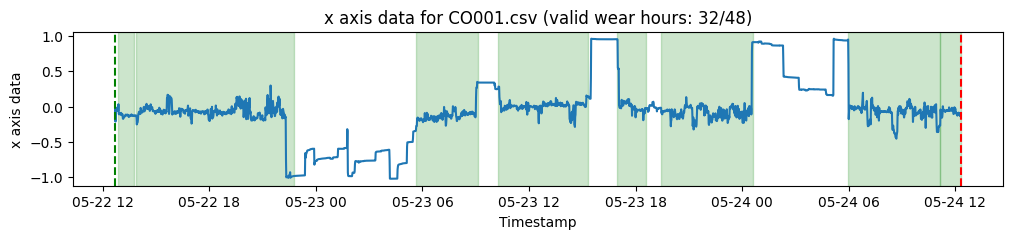

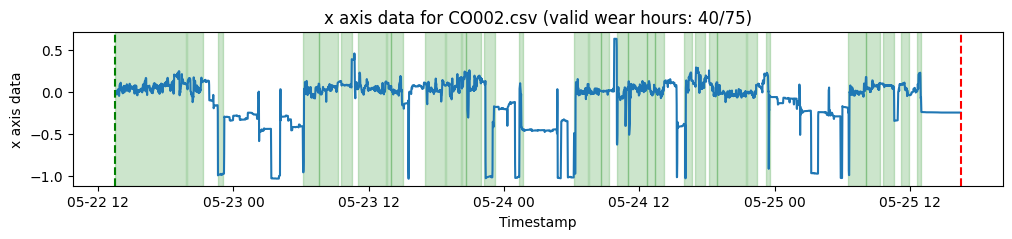

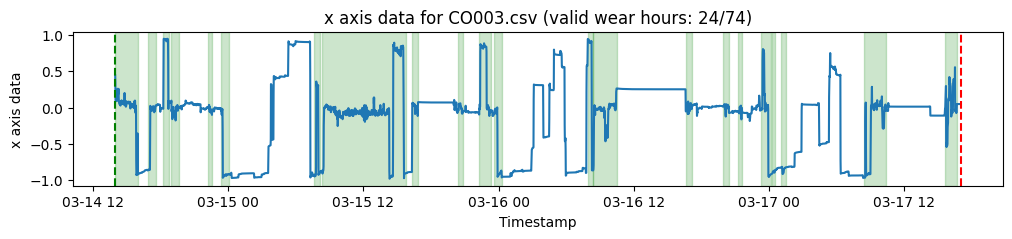

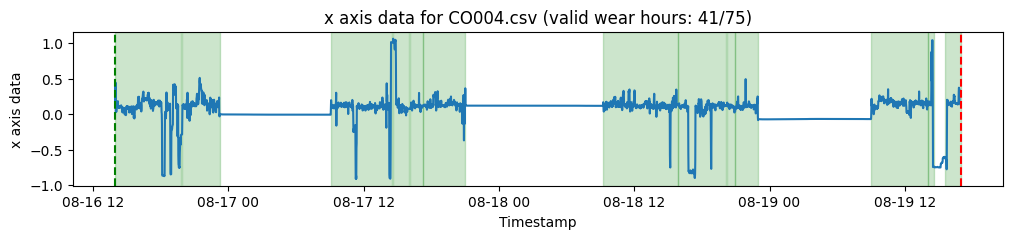

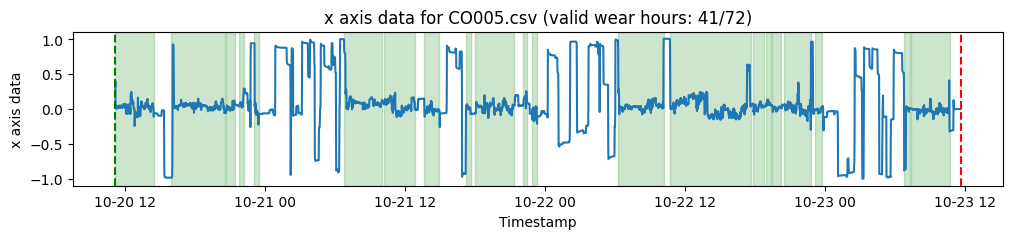

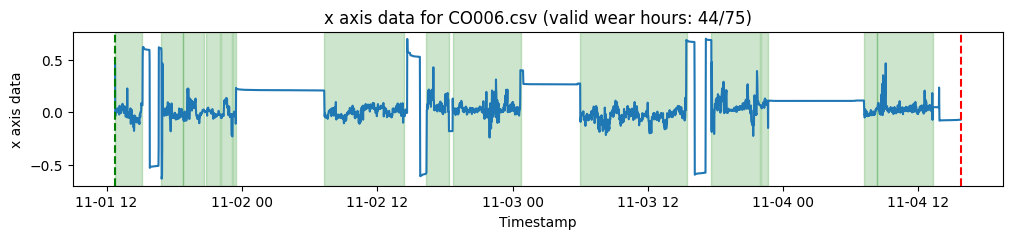

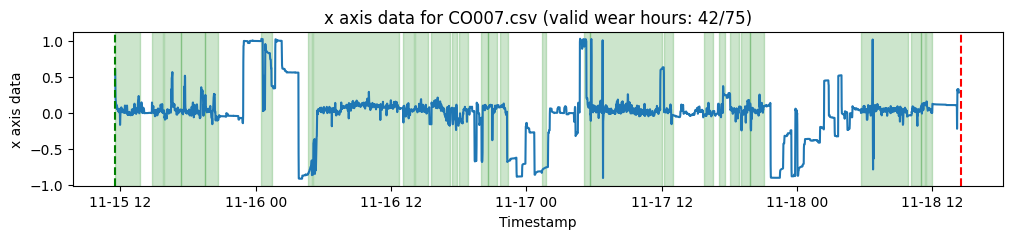

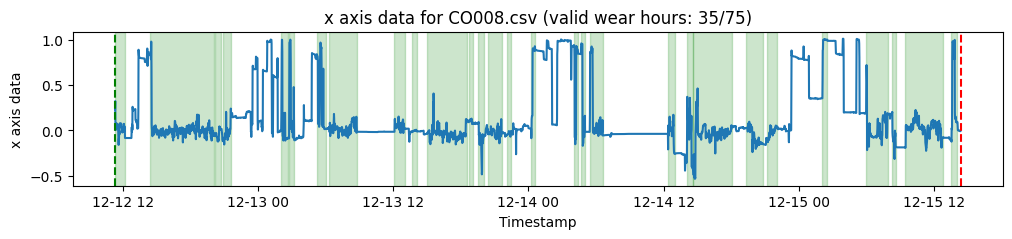

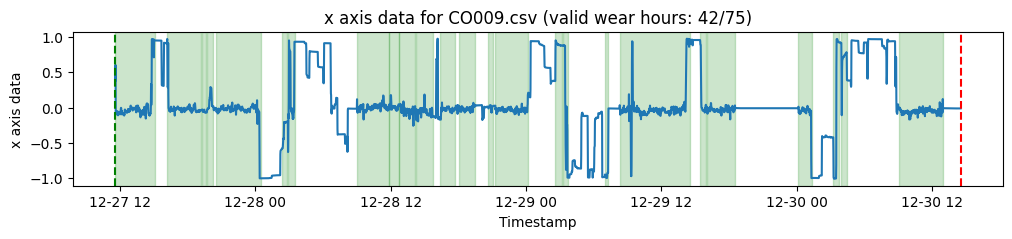

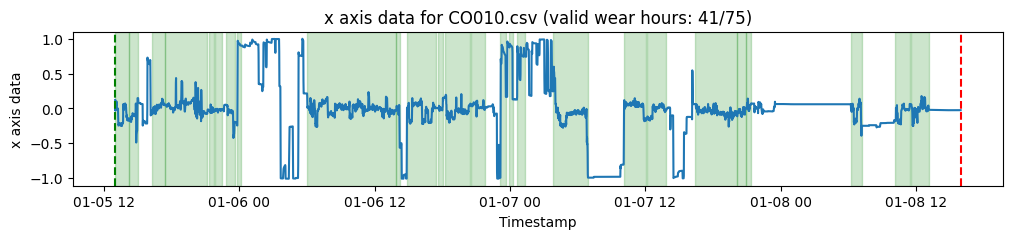

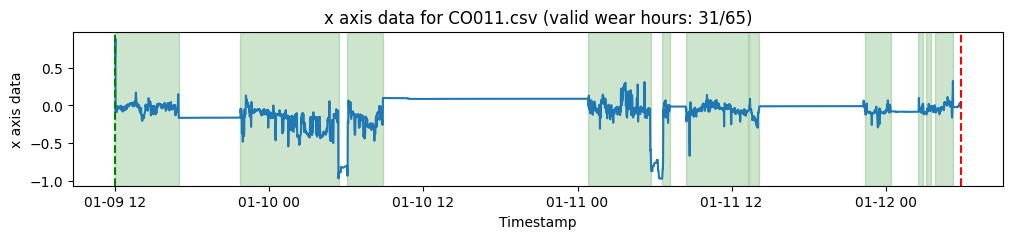

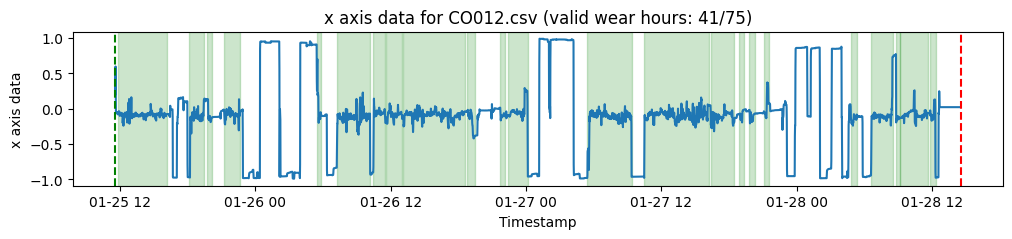

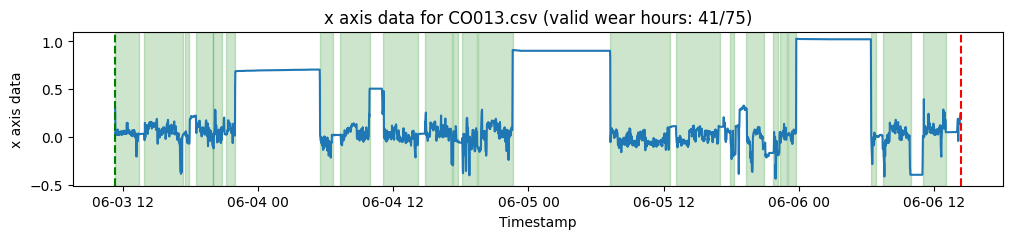

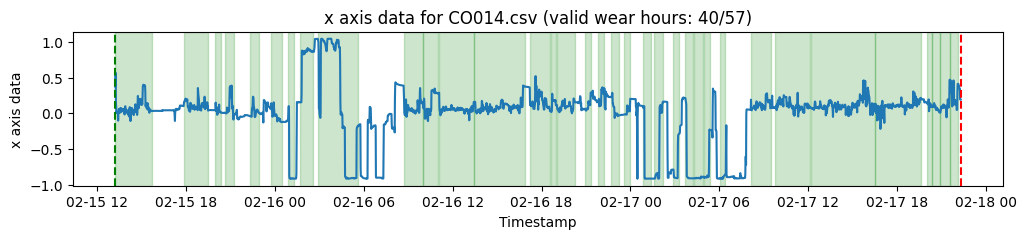

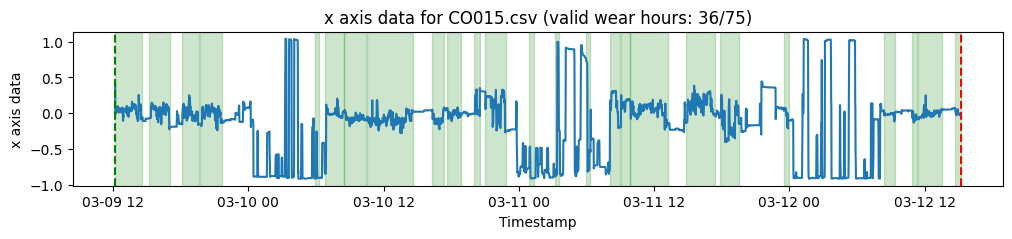

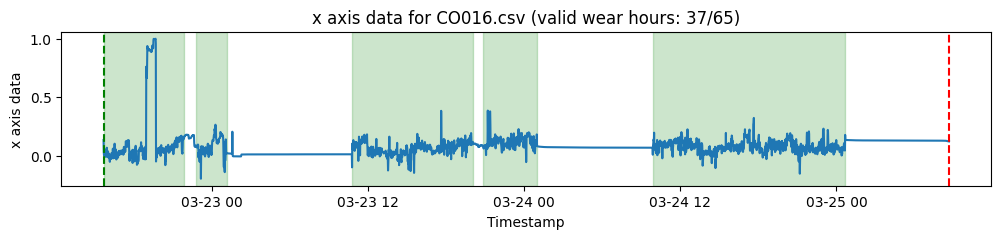

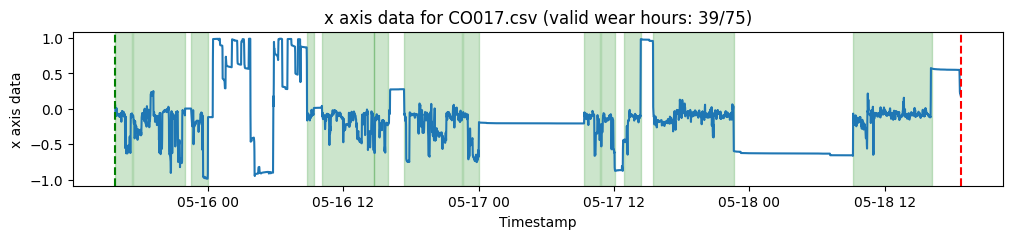

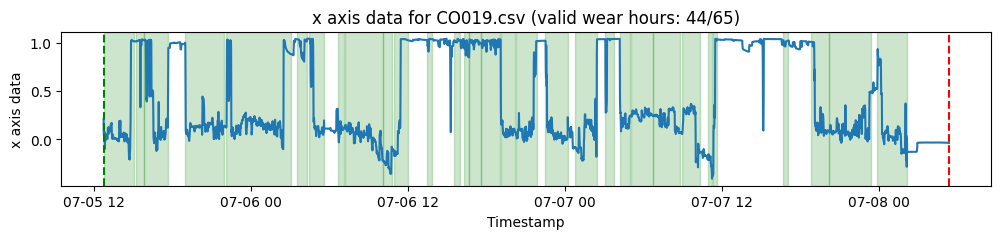

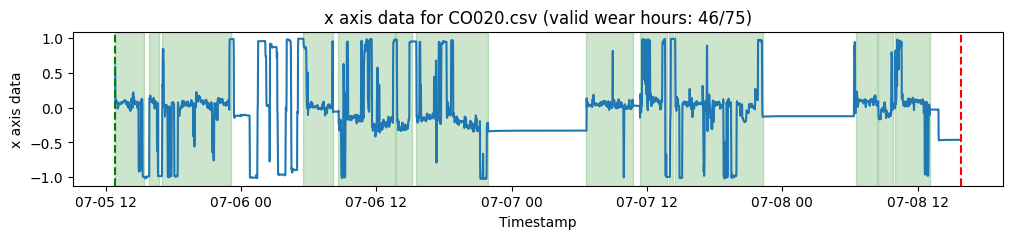

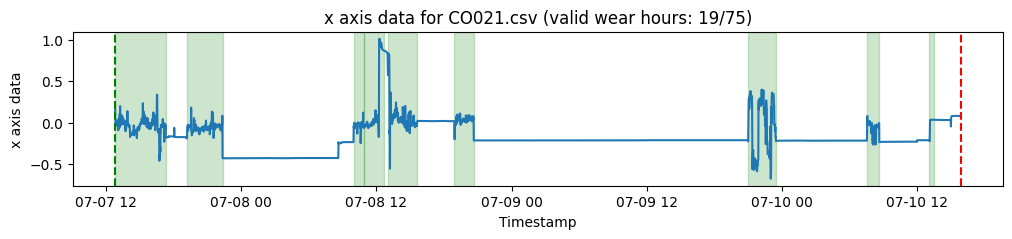

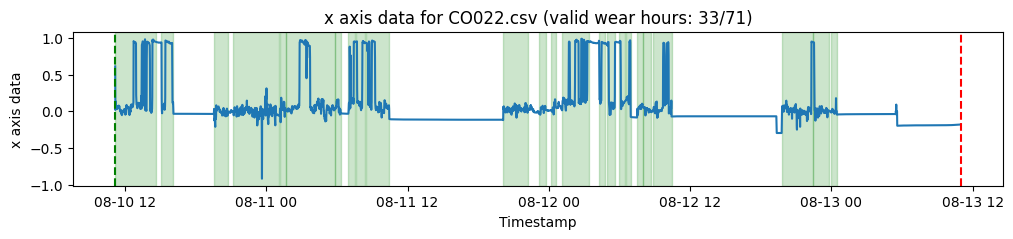

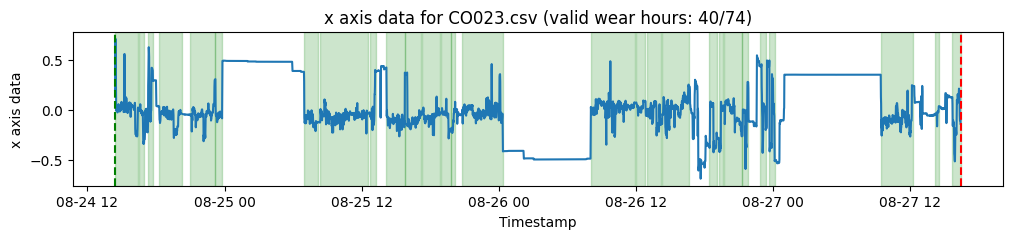

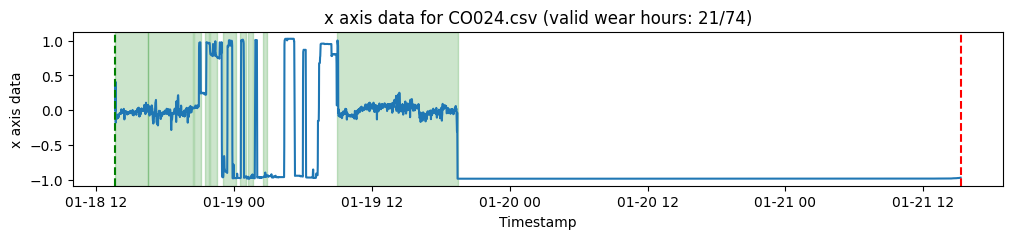

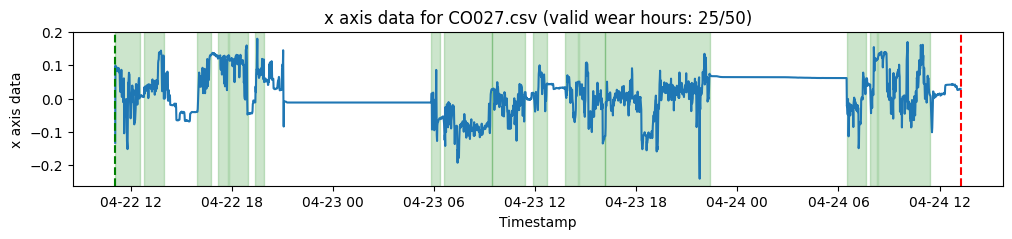

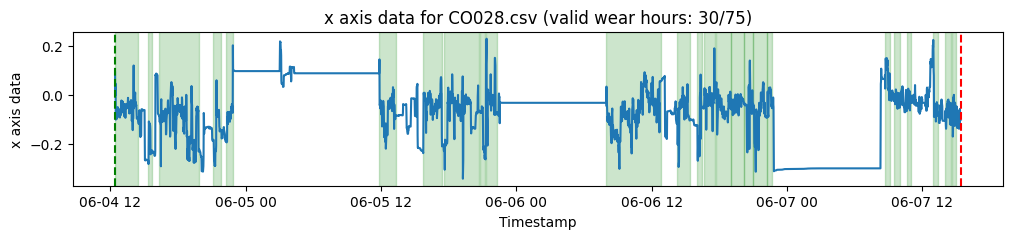

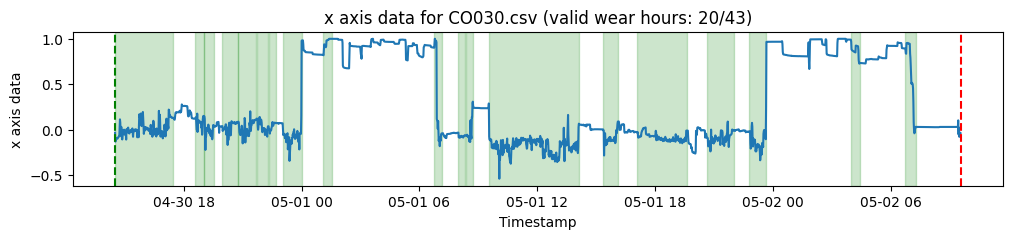

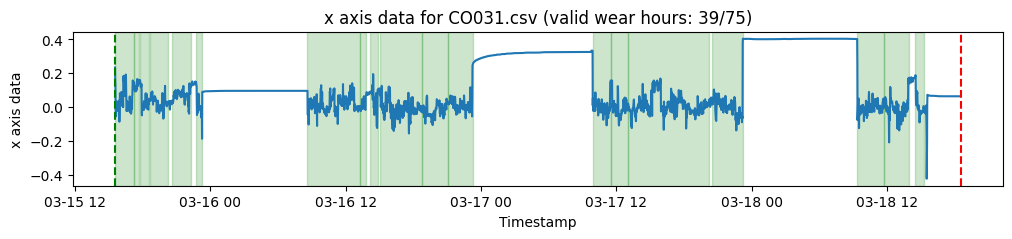

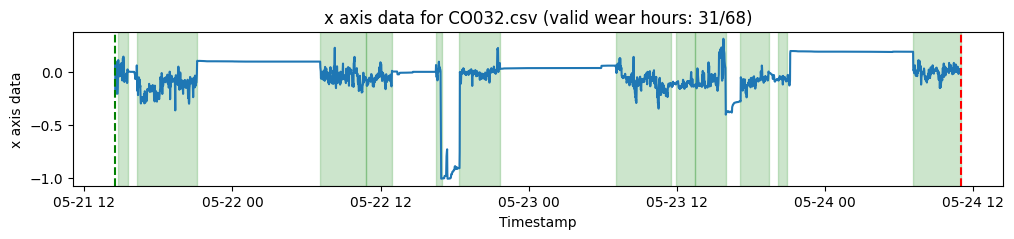

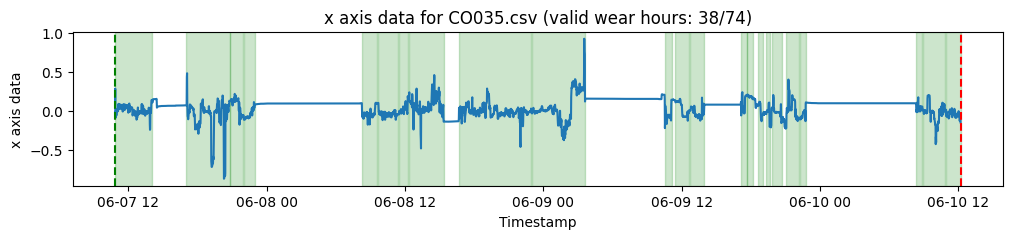

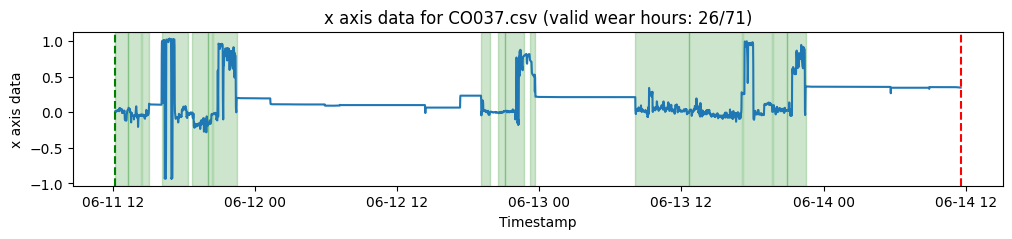

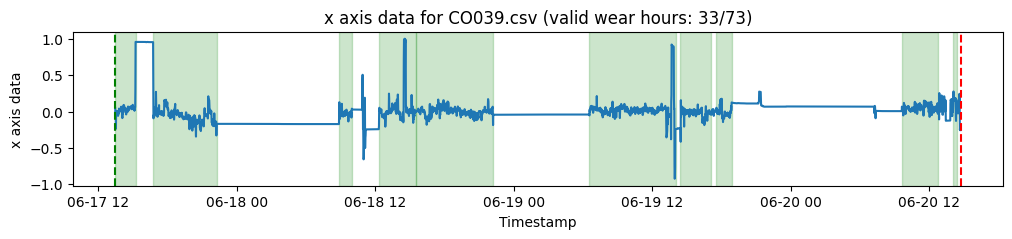

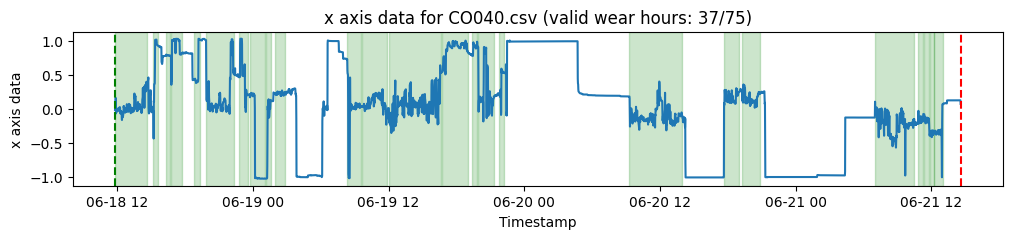

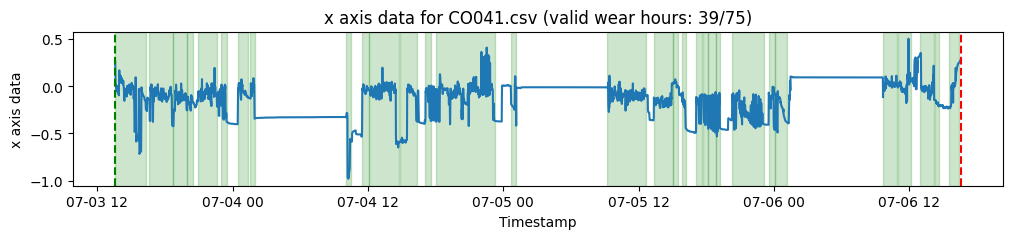

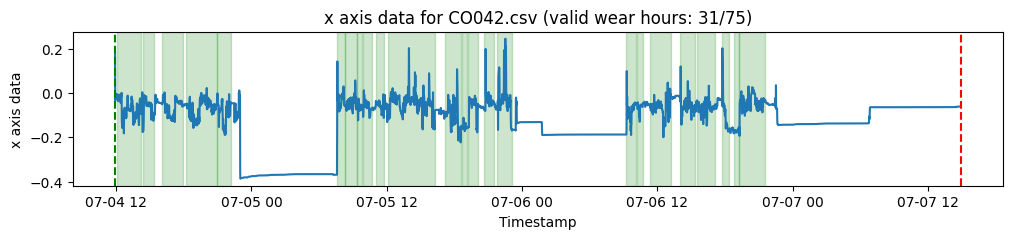

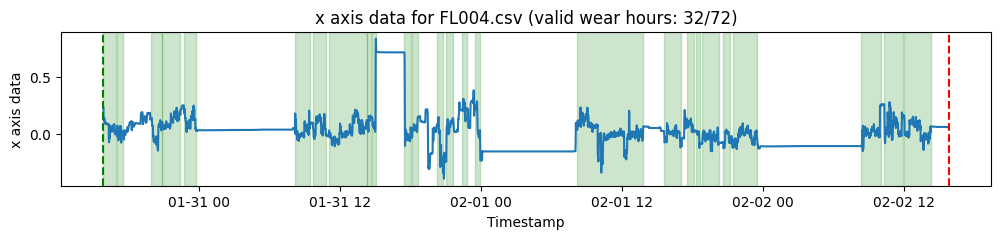

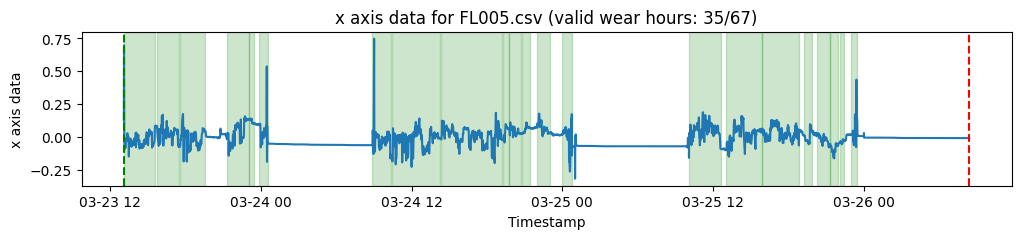

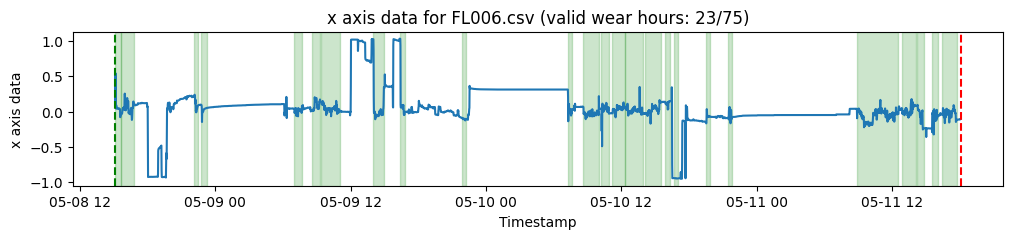

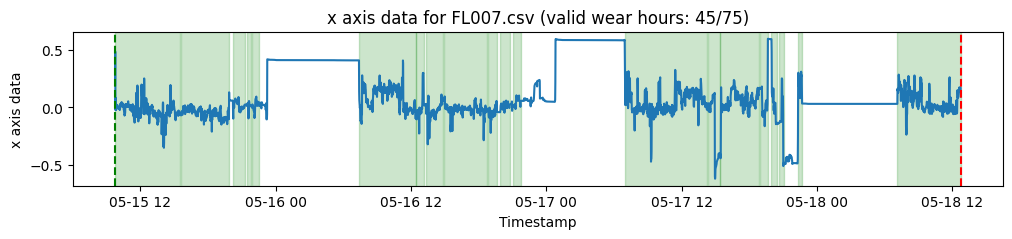

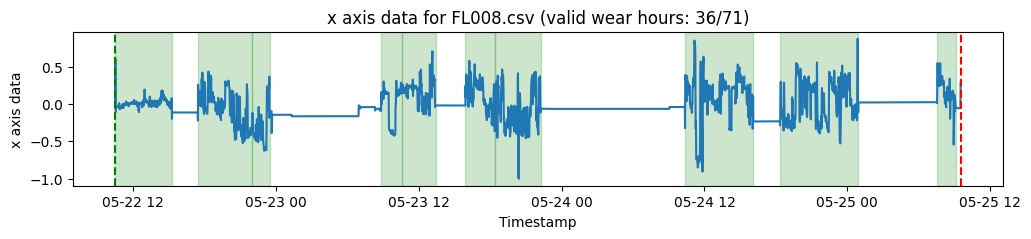

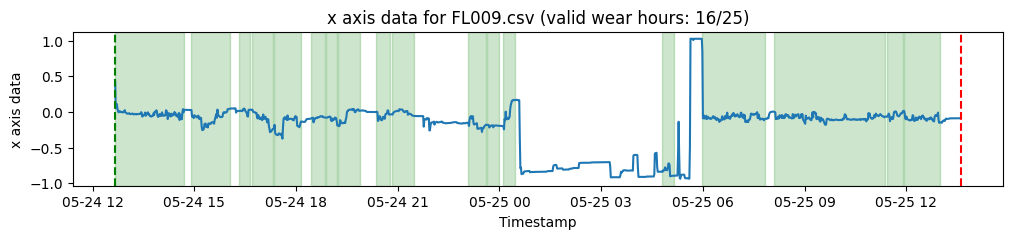

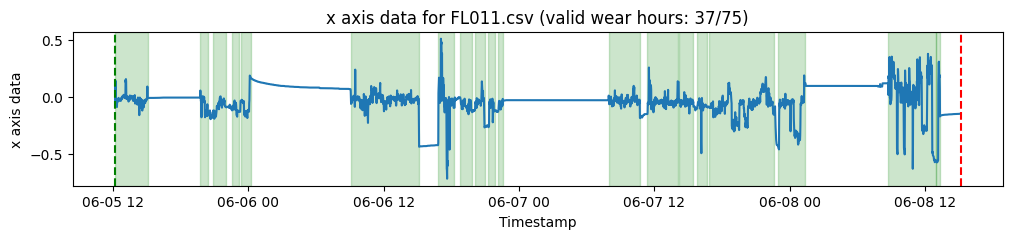

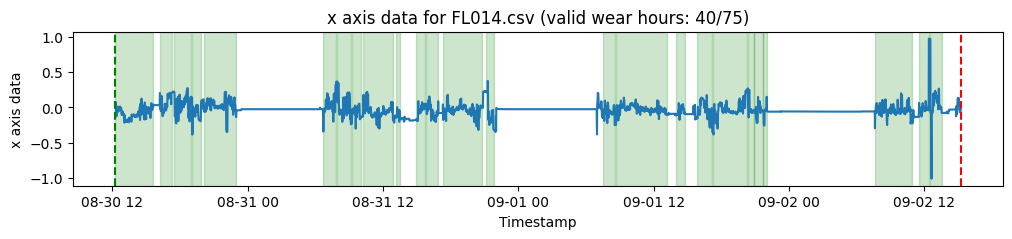

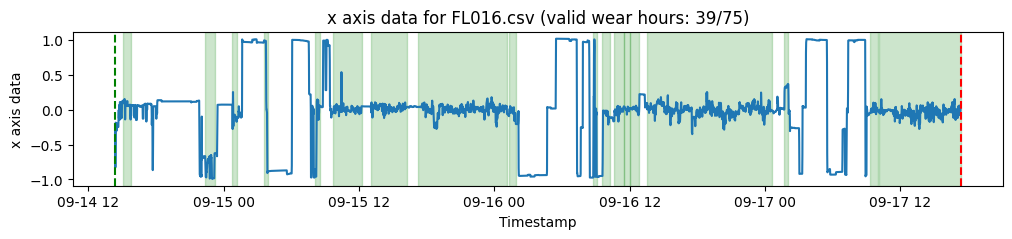

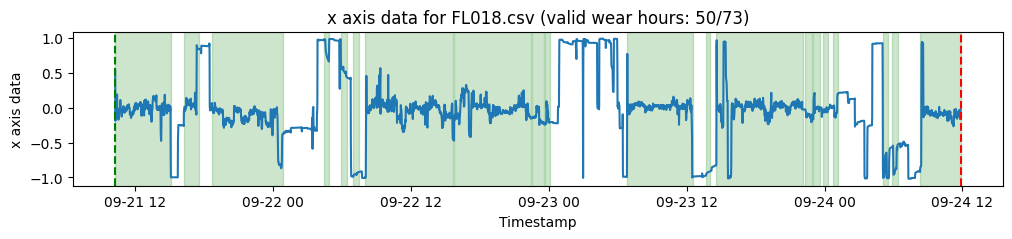

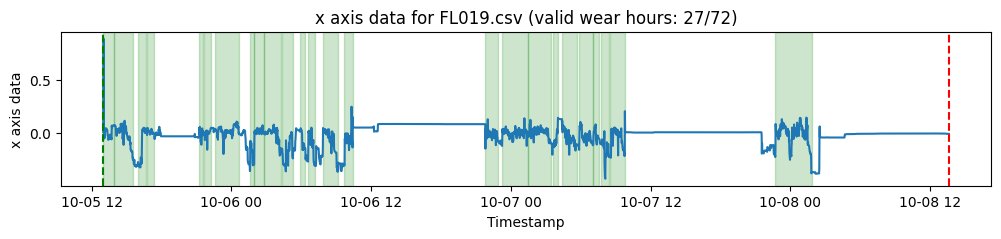

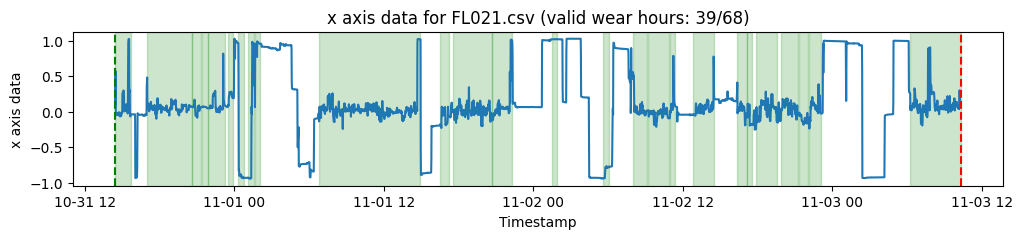

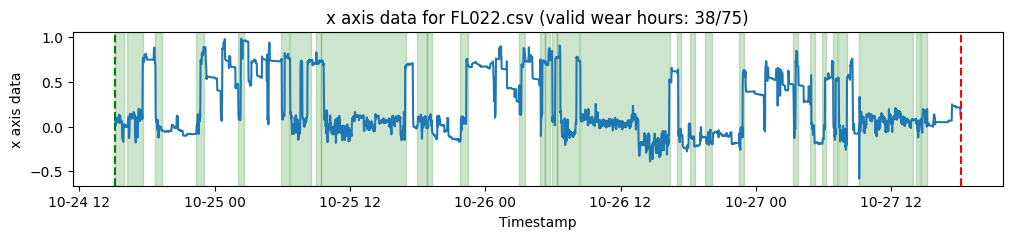

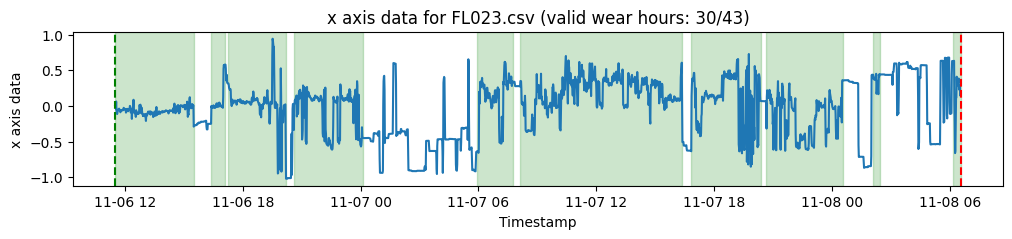

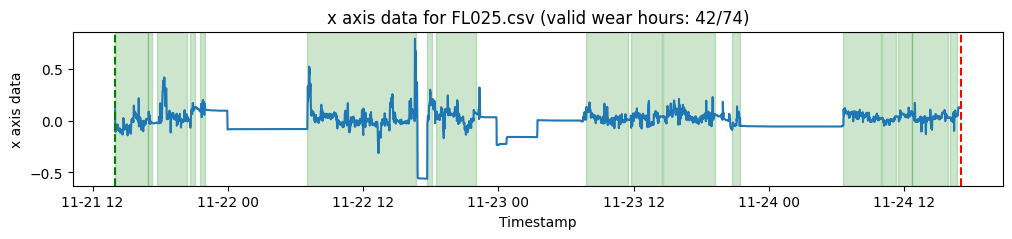

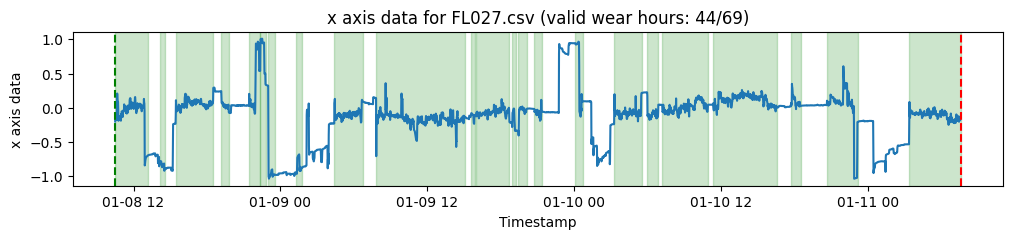

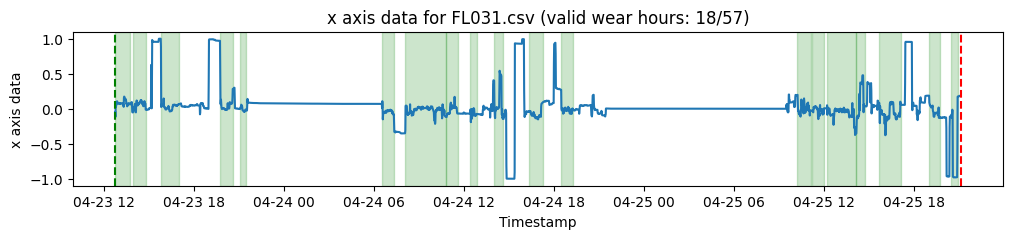

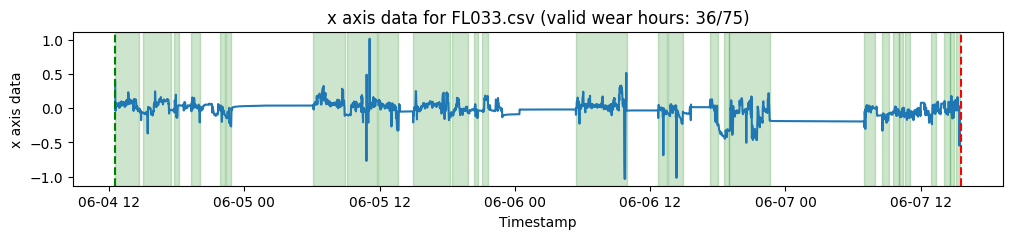

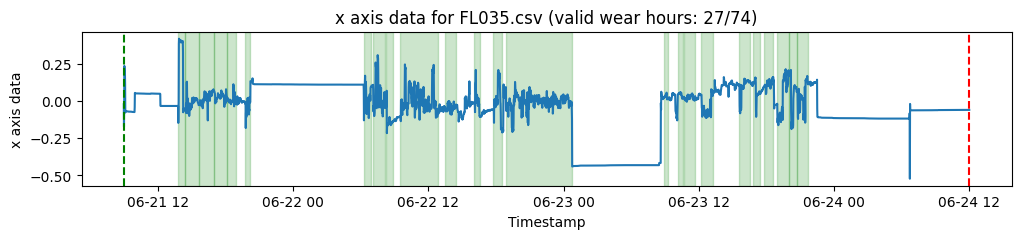

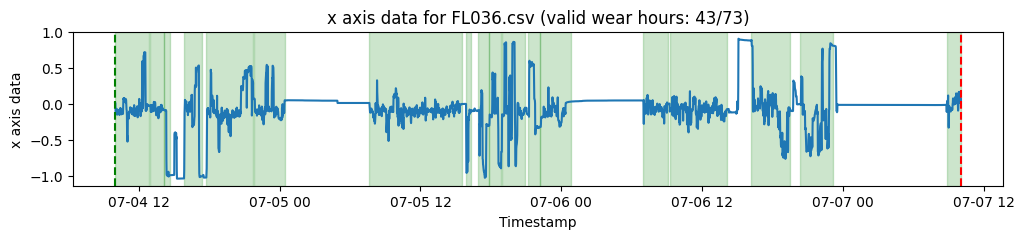

In [2]:
recompute_wear_periods(    
    sd_crit=0.015,
    range_crit=0.003,
    window_length=20,
    min_duration_minutes_wear=20
)
plot_pig_wear_timeseries("wear_periods_recomputed.csv", "minute_level", limit=None, axis='x')

### Modification of values during during non-wear periods

During day time the mean of the timeseries is taken and during night time the values are set to 0.


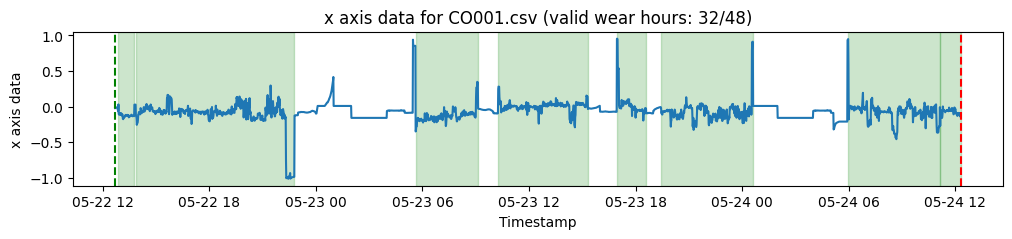

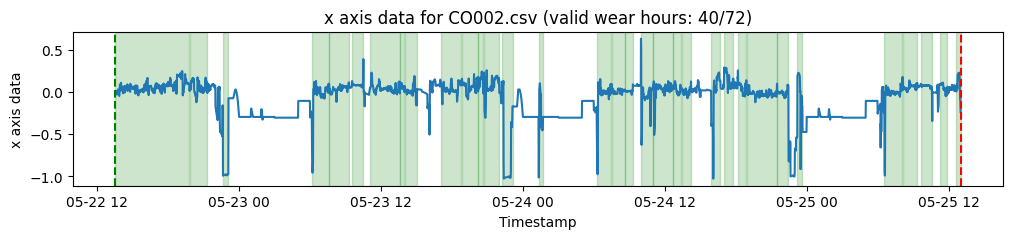

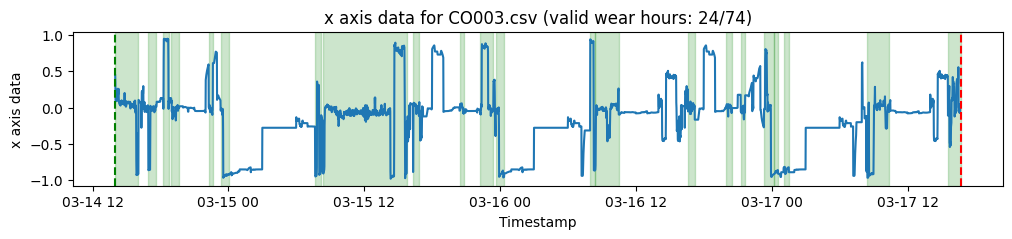

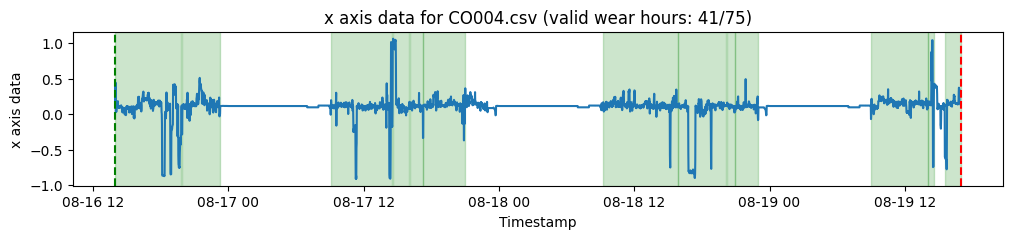

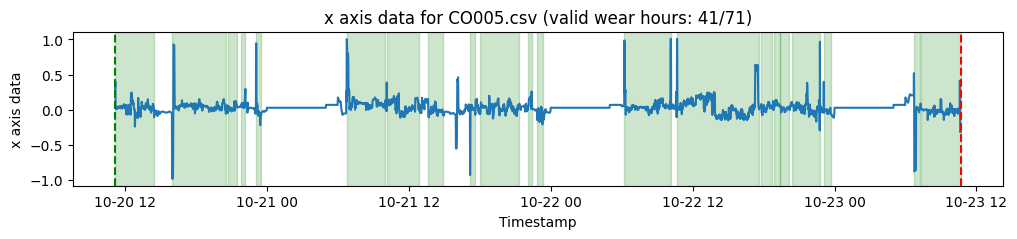

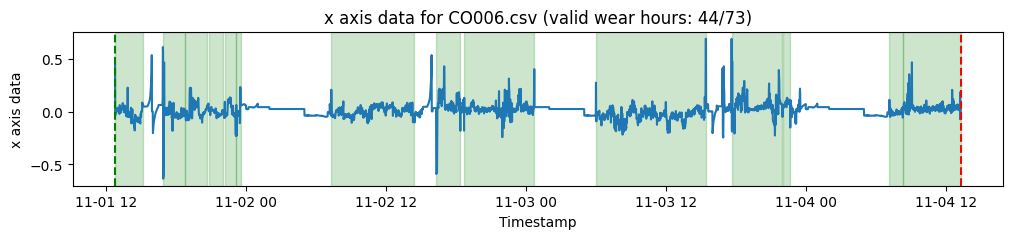

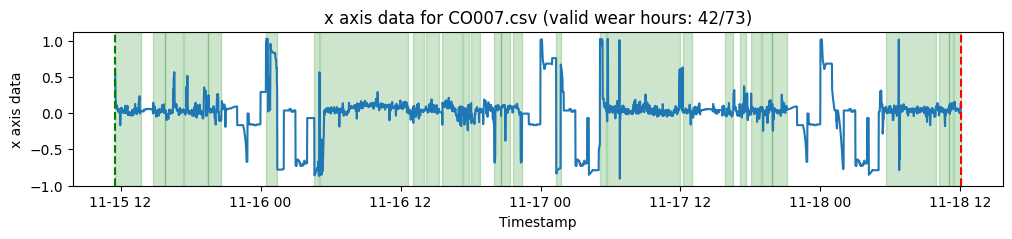

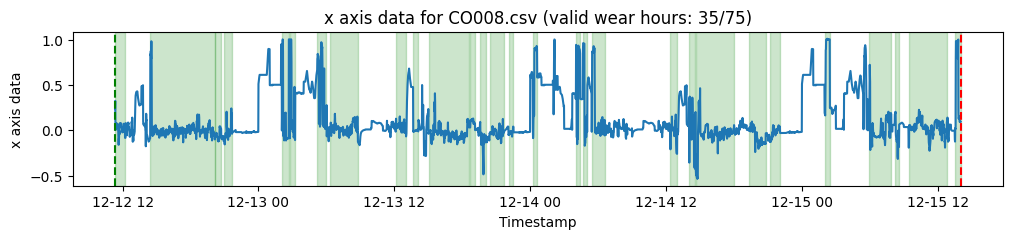

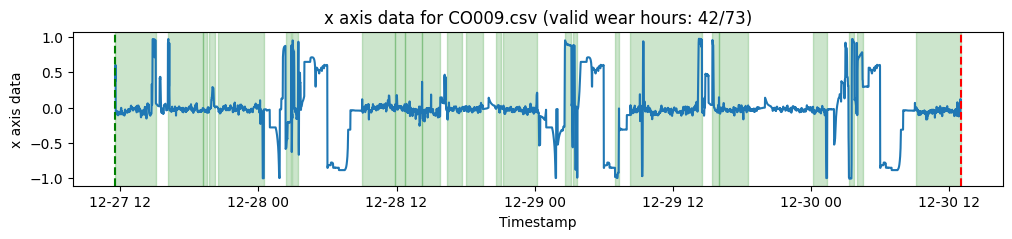

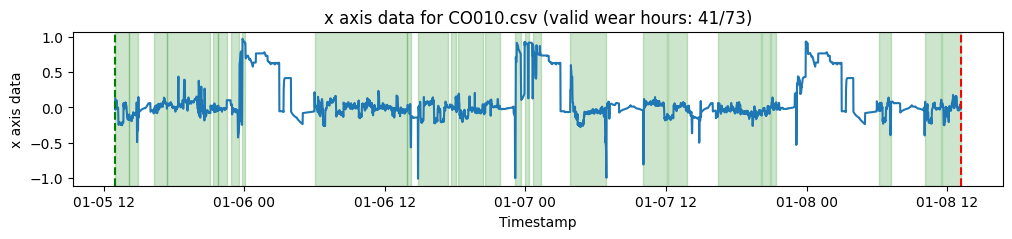

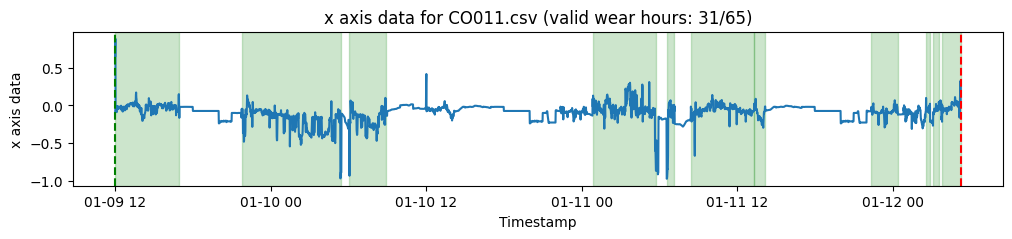

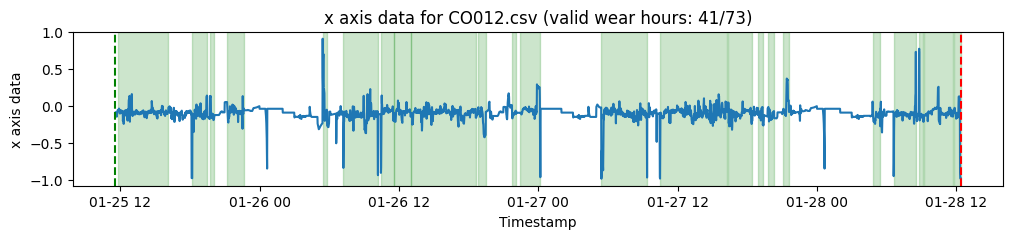

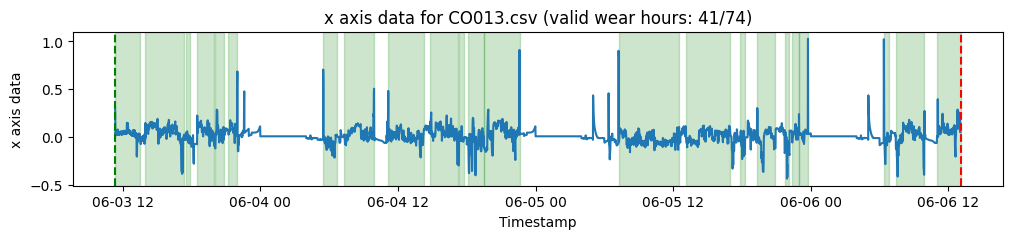

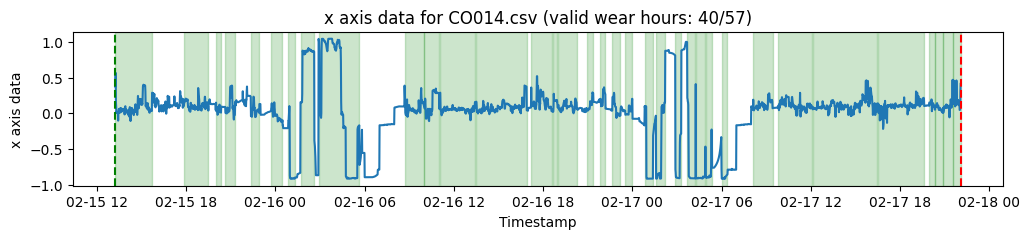

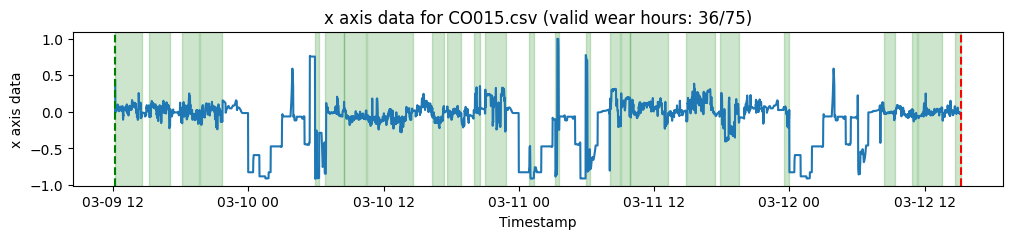

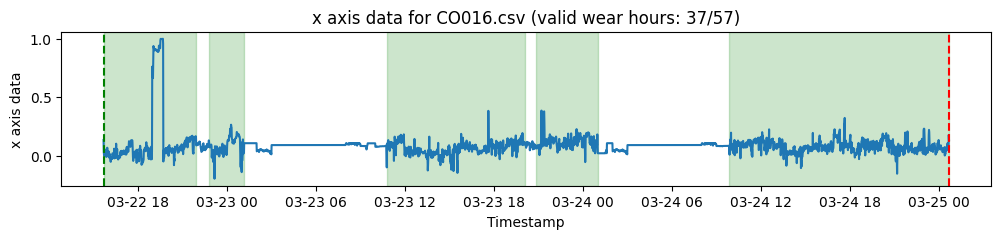

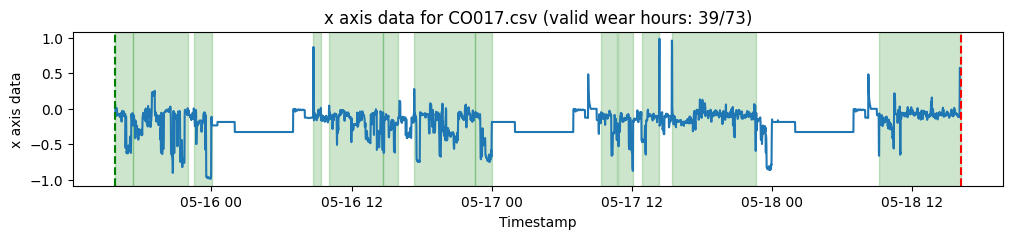

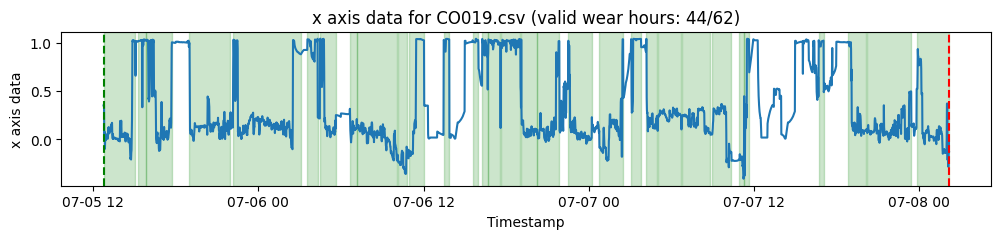

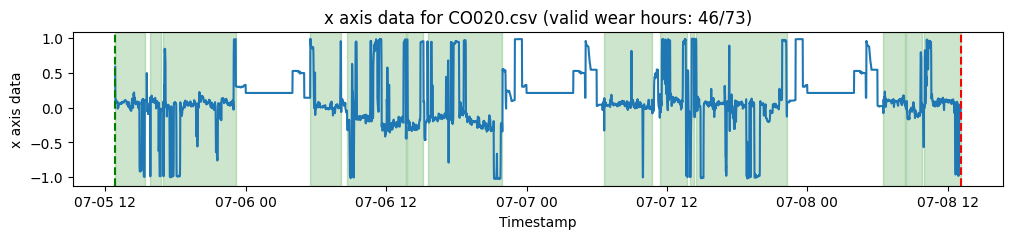

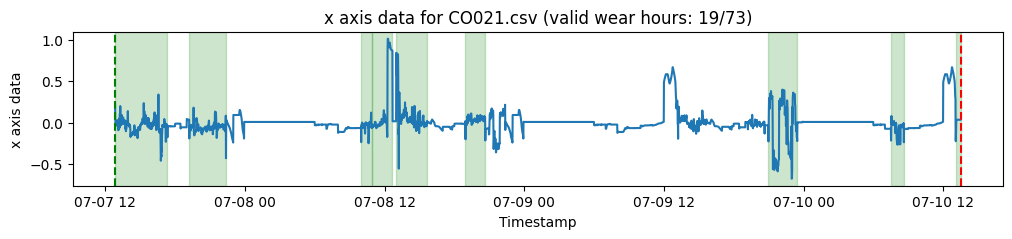

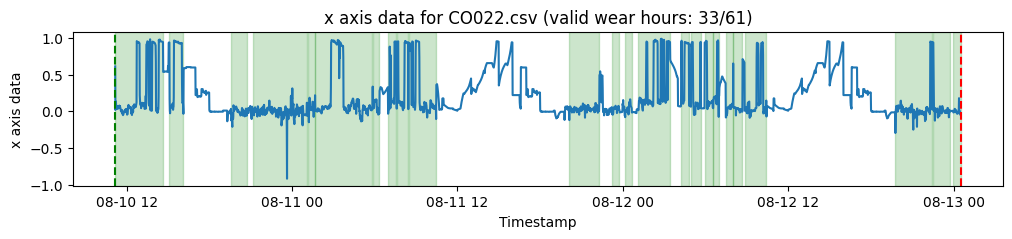

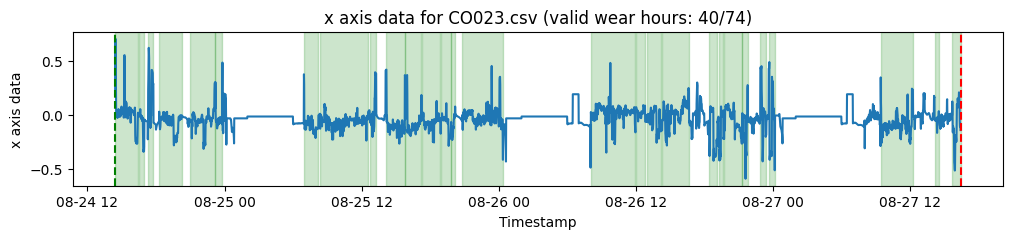

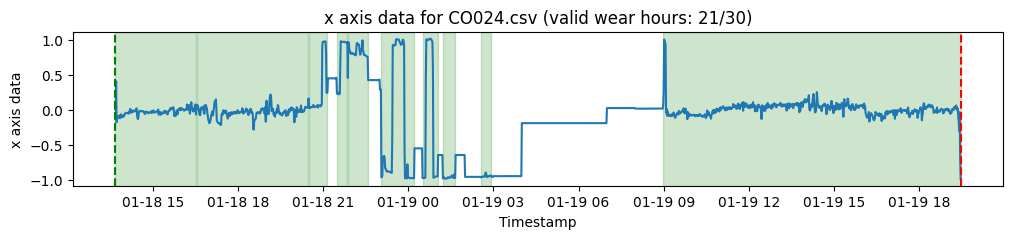

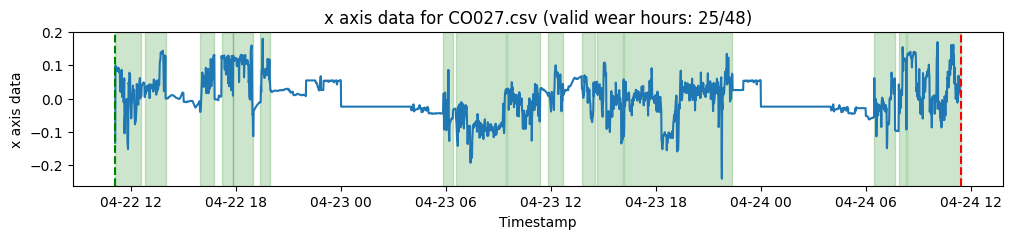

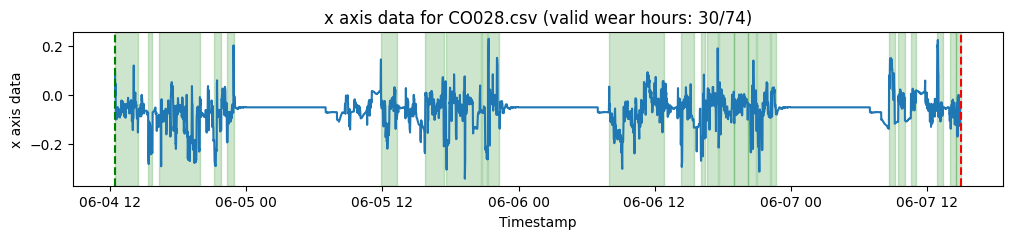

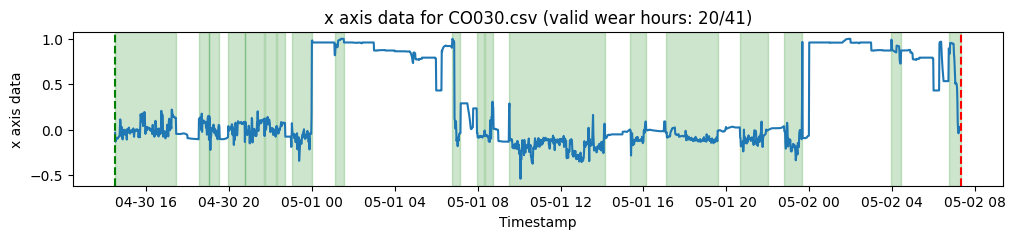

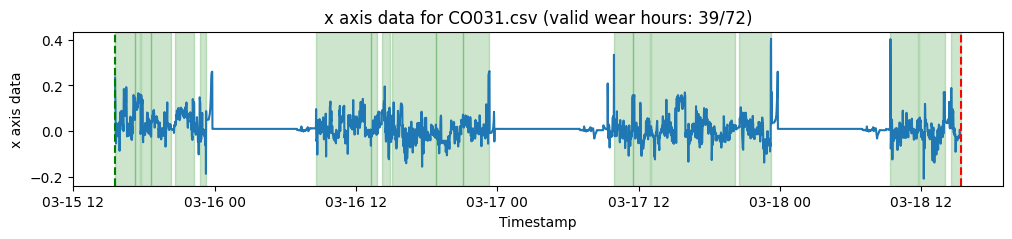

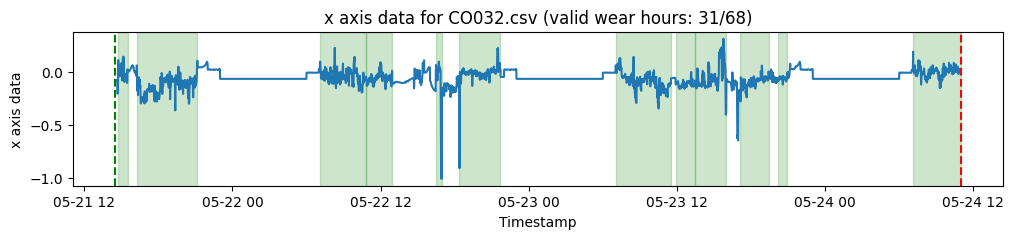

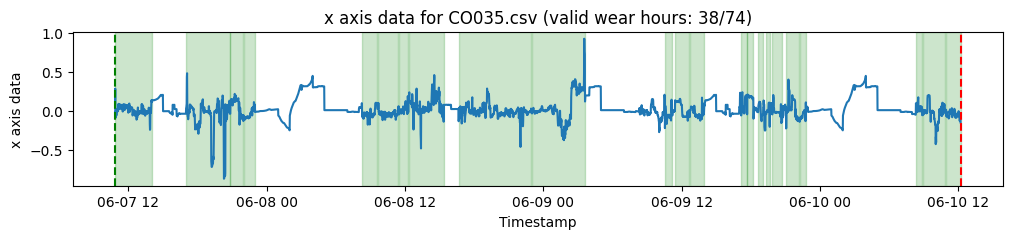

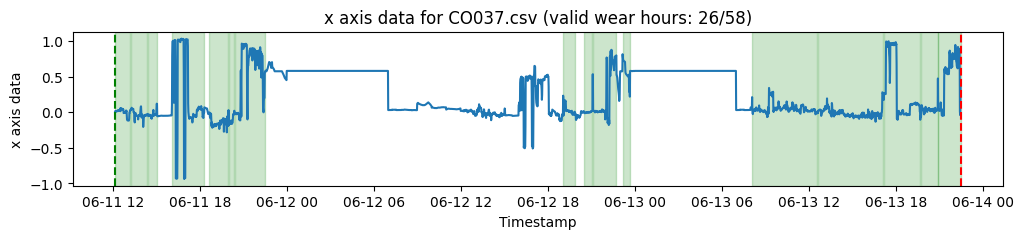

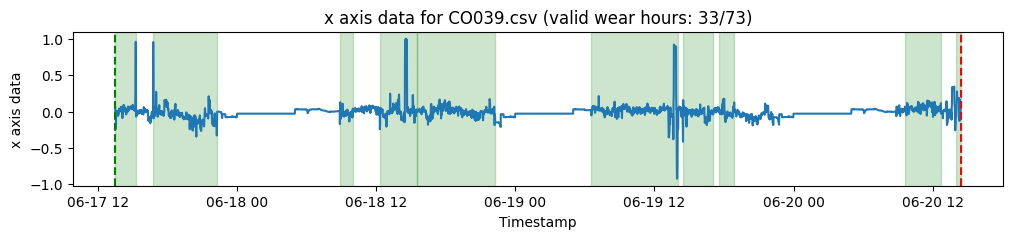

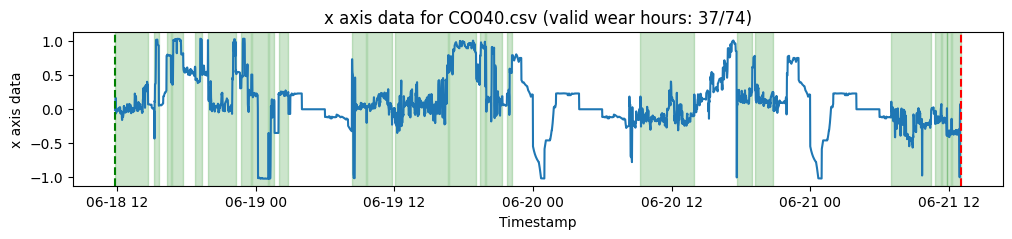

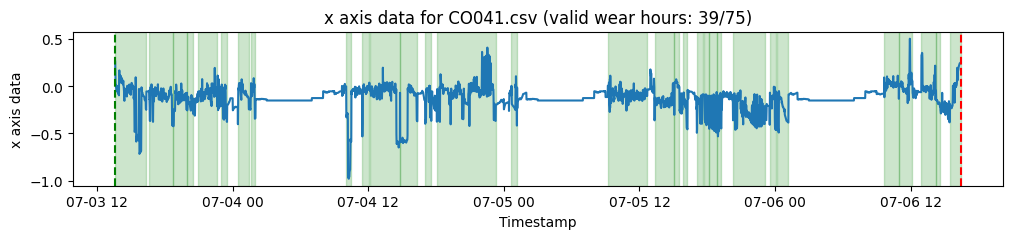

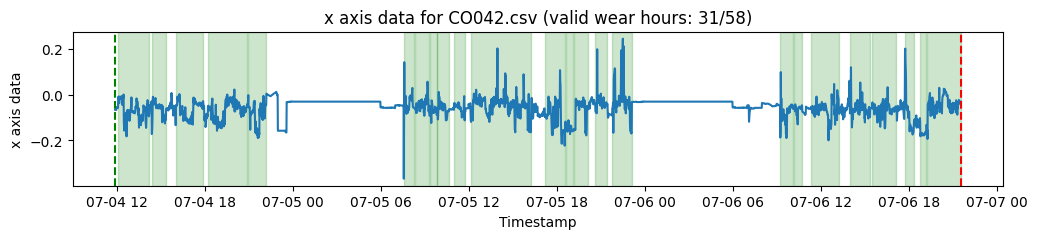

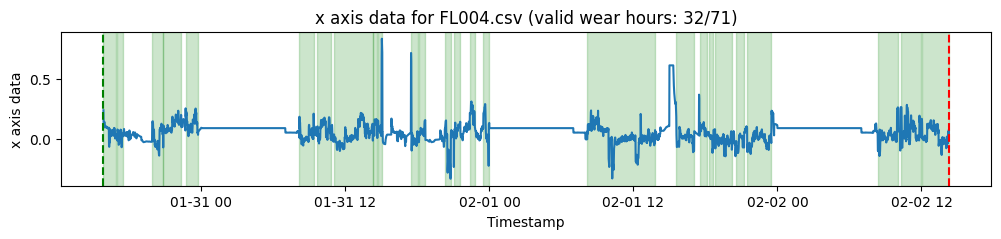

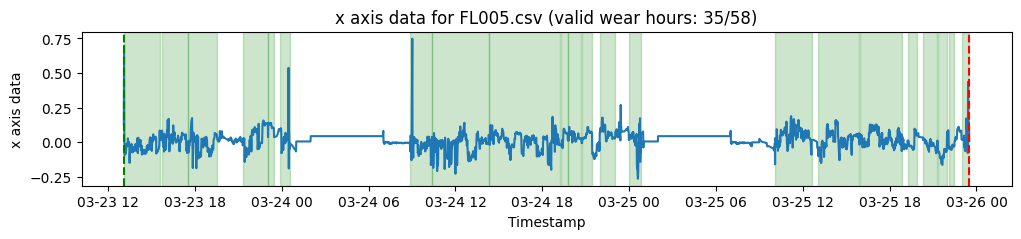

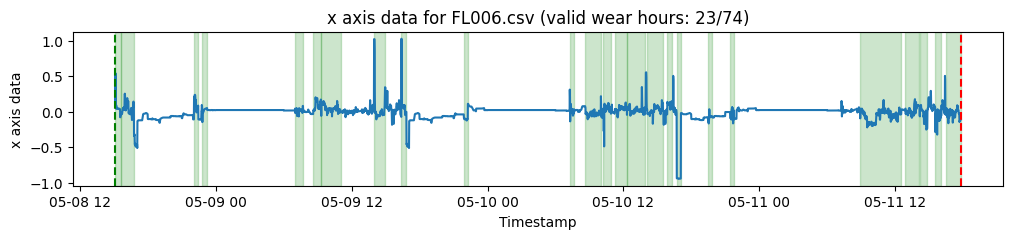

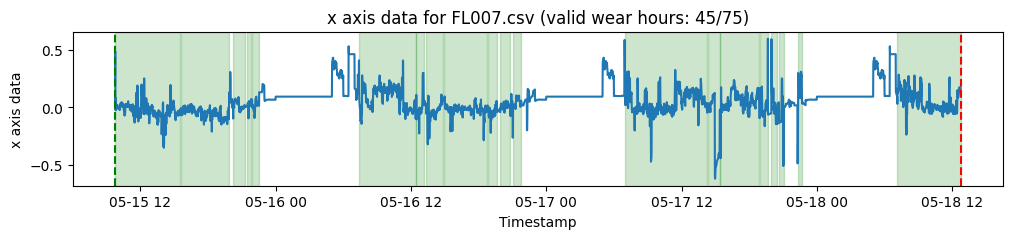

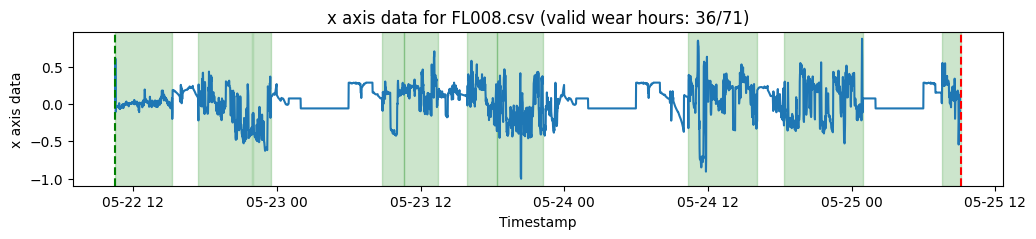

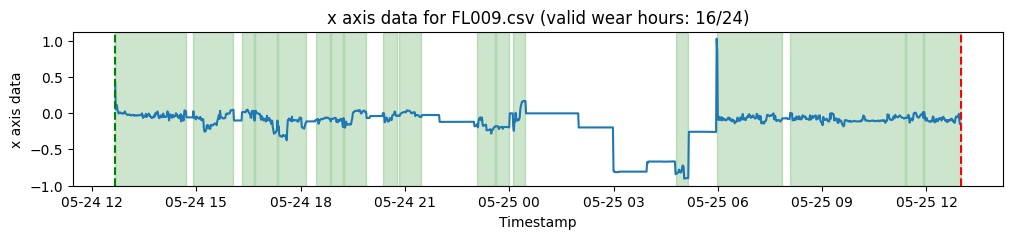

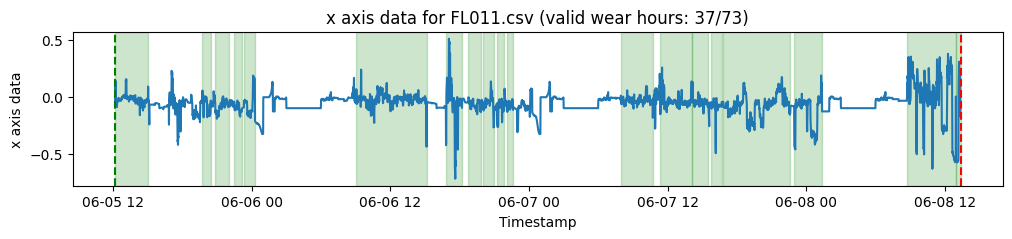

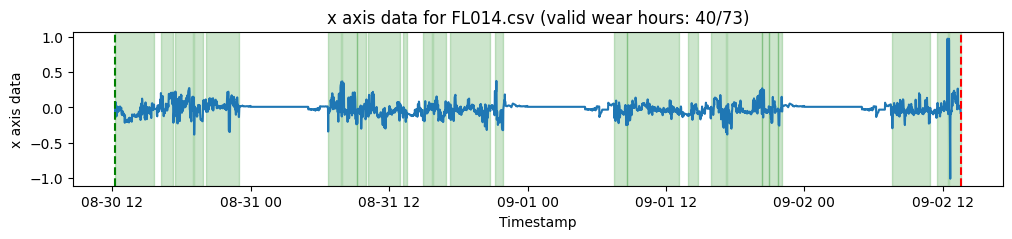

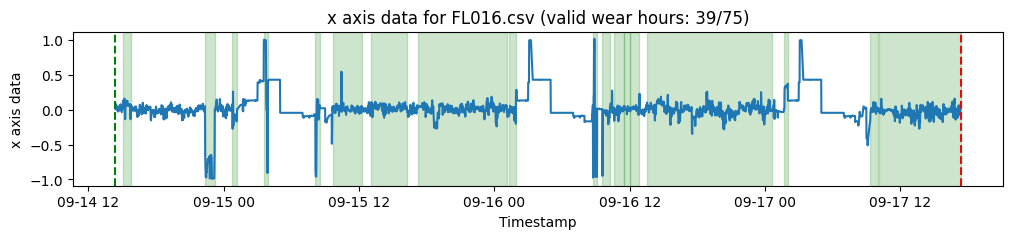

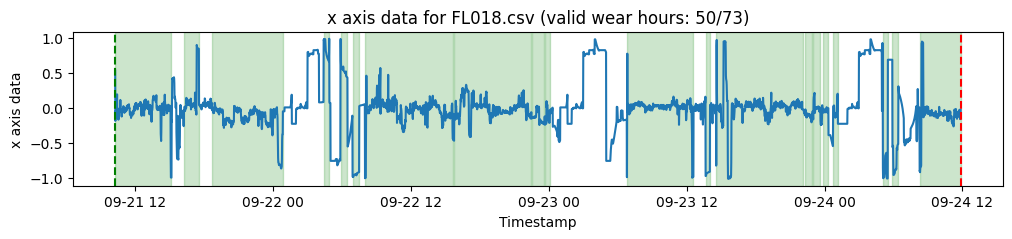

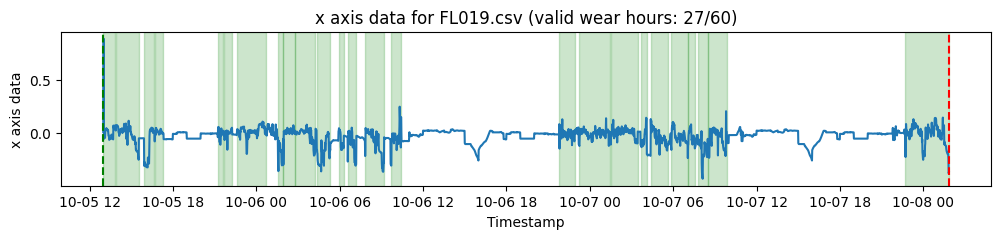

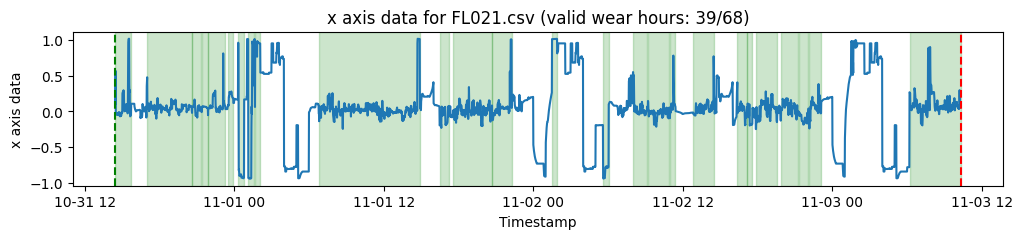

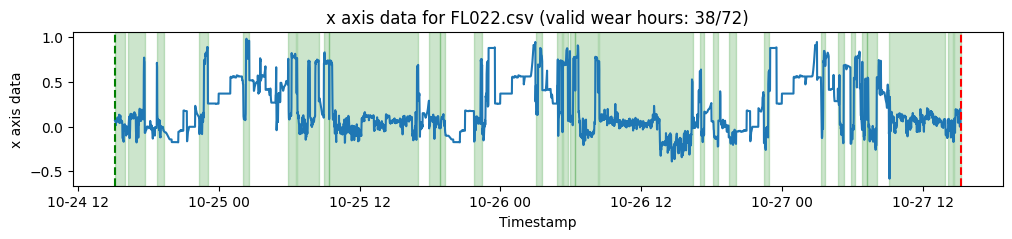

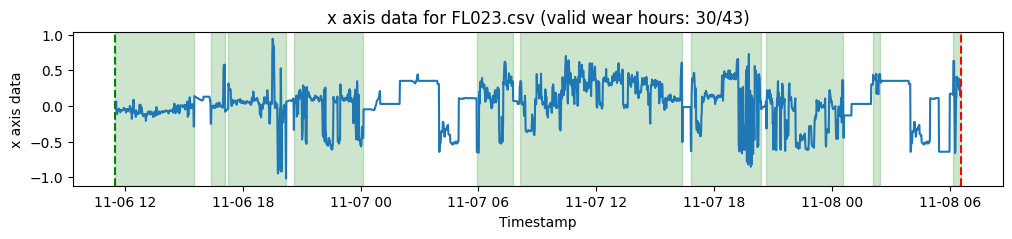

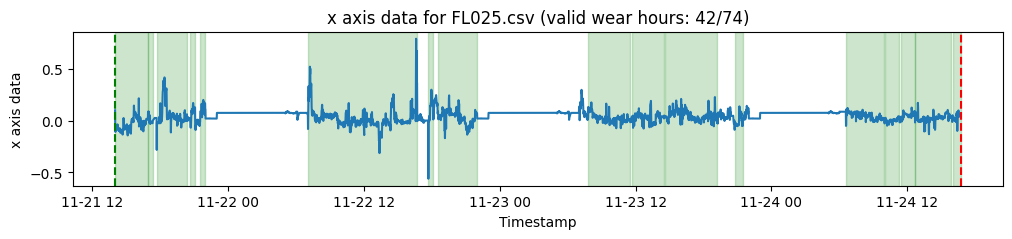

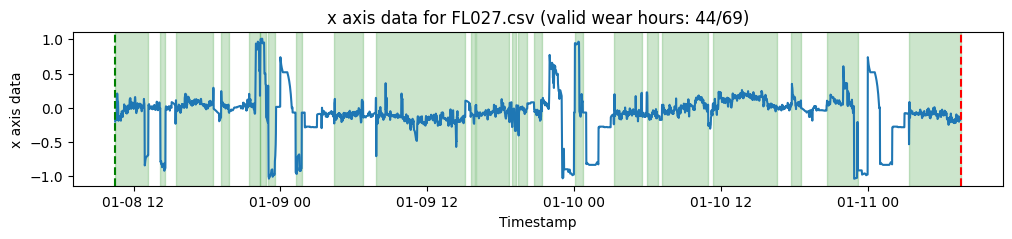

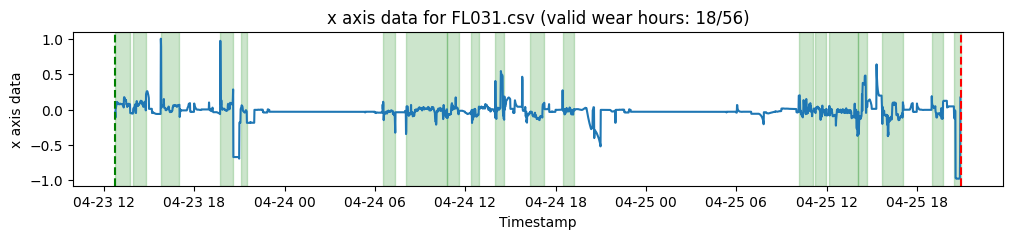

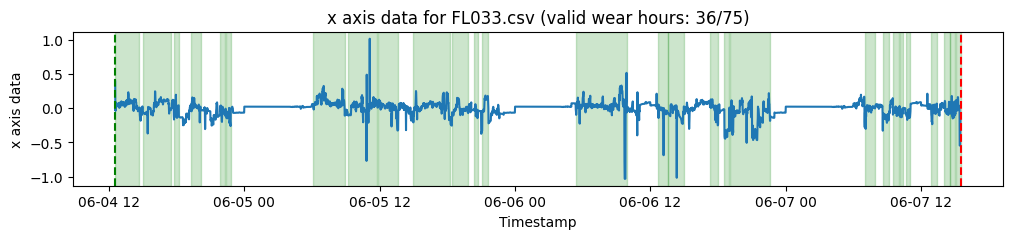

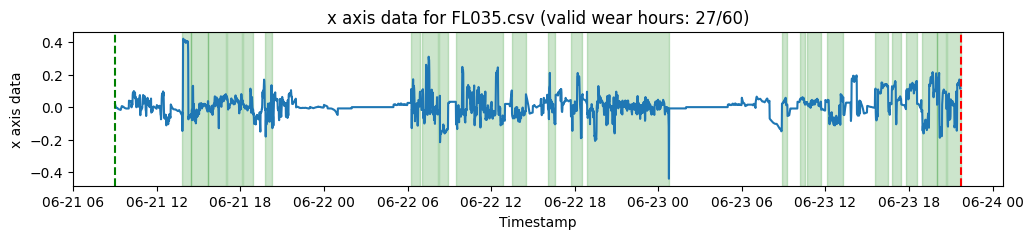

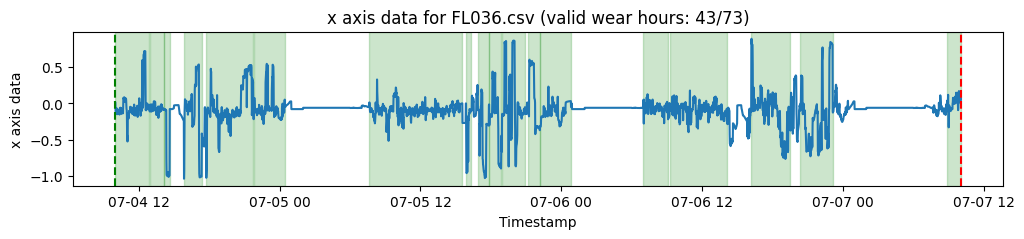

In [3]:
save_modified_timeseries("wear_periods_recomputed.csv", "minute_level", output_dir="minute_level_modified", max_wear_periods=1000, day_start="07:00", day_end="22:00", smart=True)
plot_pig_wear_timeseries("wear_periods_recomputed.csv", "minute_level_modified", limit=None, axis='x')

### Average circadian rhythm per cohort 

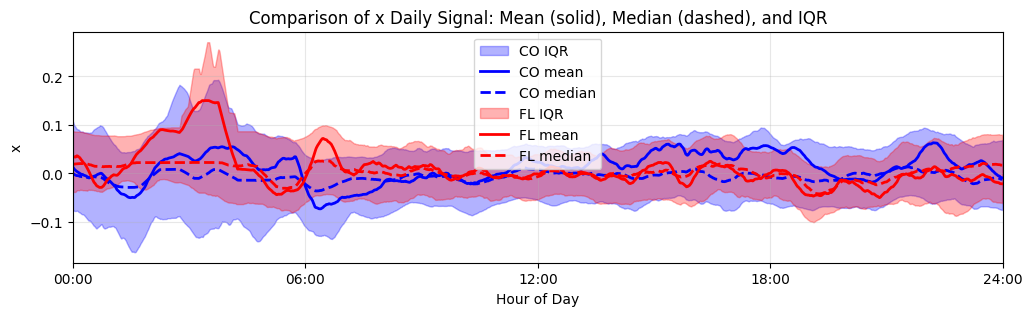

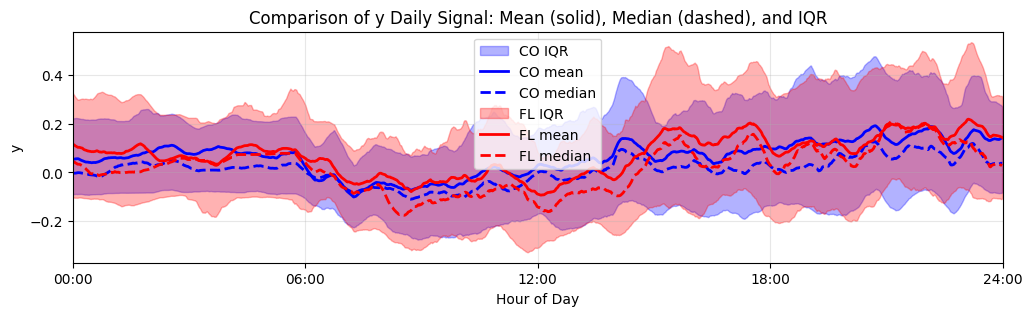

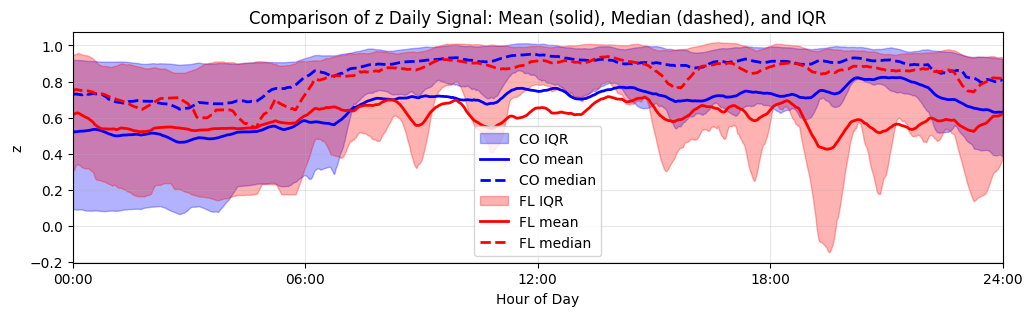

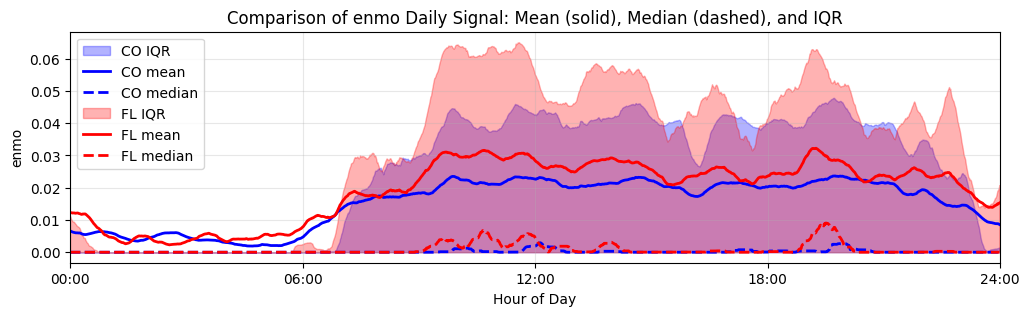

In [4]:
compare_cohorts_daily_signal(co_pattern="CO*.csv", fl_pattern="FL*.csv", folder="minute_level_modified", columns=['x','y','z','enmo'], window=30, plot_minmax=False)

### CosinorAge analysis per cohort

In [5]:
co_handlers, co_cosinor_age_inputs = load_cohort_data(modified_dir="minute_level_modified", header_dir="headers", pattern="CO*.csv", preprocess_args=None)
fl_handlers, fl_cosinor_age_inputs = load_cohort_data(modified_dir="minute_level_modified", header_dir="headers", pattern="FL*.csv", preprocess_args=None)

features_args = {}

co_features = csa.features.BulkWearableFeatures(
    handlers=co_handlers, 
    features_args=features_args,
    compute_distributions=True,
    cosinor_age_inputs=co_cosinor_age_inputs
    )

fl_features = csa.features.BulkWearableFeatures(
    handlers=fl_handlers, 
    features_args=features_args,
    compute_distributions=True,
    cosinor_age_inputs=fl_cosinor_age_inputs
    )

Error processing CO024.csv: Less than 1 day found
Error processing FL009.csv: Less than 1 day found


In [6]:
co_features.get_summary_dataframe()

,feature,count,mean,std,min,max,median,q25,q75,iqr,mode,skewness
0,cosinor_mesor,33,14.262680,15.030557,0.018932,47.649091,9.041919,1.446259,22.278754,20.832495,0.018932,1.114067
1,cosinor_amplitude,33,10.701660,10.697587,0.023132,39.585245,7.432710,2.481385,15.467522,12.986137,0.023132,1.273691
2,cosinor_acrophase,33,-3.189945,1.488365,-5.949642,-0.436489,-3.572524,-4.120695,-1.600728,2.519966,-5.949642,0.296342
3,cosinor_acrophase_time,33,731.081652,341.108049,100.035805,1363.557560,818.762258,366.859940,944.393656,577.533716,100.035805,-0.296342
4,nonparam_IS,33,0.778185,0.183581,0.356126,1.000000,0.828250,0.609063,0.911418,0.302355,1.000000,-0.620662
5,nonparam_IV,33,1.054073,0.575537,0.269411,2.190908,0.847199,0.580603,1.333579,0.752975,0.269411,0.807929
6,nonparam_M10,33,23.158424,22.862432,0.045437,74.467329,16.288345,3.261059,38.536833,35.275774,0.045437,1.067426
7,nonparam_L5,33,0.407441,1.226074,0.000000,6.858149,0.000000,0.000000,0.025225,0.025225,0.000000,4.665893
8,nonparam_RA,33,0.972944,0.059053,0.760664,1.000000,1.000000,0.998727,1.000000,0.001273,1.000000,-2.380066
9,physical_activity_sedentary,33,972.742424,354.316246,114.000000,1438.500000,1022.000000,688.000000,1313.500000,625.500000,114.000000,-0.422855


In [7]:
fl_features.get_summary_dataframe()

,feature,count,mean,std,min,max,median,q25,q75,iqr,mode,skewness
0,cosinor_mesor,19,20.350292,18.675888,0.017396,51.417714,17.714711,1.874174,38.028877,36.154703,0.017396,0.473097
1,cosinor_amplitude,19,15.631354,15.115200,0.034488,46.931997,8.972259,2.999387,26.772932,23.773545,0.034488,0.795622
2,cosinor_acrophase,19,-4.196925,1.136233,-6.183849,-1.565471,-4.159343,-5.127094,-3.303214,1.823880,-6.183849,0.245570
3,cosinor_acrophase_time,19,961.864337,260.405328,358.779586,1417.233799,953.251136,757.040808,1175.043346,418.002538,358.779586,-0.245570
4,nonparam_IS,19,0.763991,0.198561,0.377262,1.000000,0.778407,0.663132,0.932784,0.269652,1.000000,-0.571454
5,nonparam_IV,19,0.839850,0.426682,0.349135,2.072794,0.859470,0.474920,1.075341,0.600421,0.349135,1.232748
6,nonparam_M10,19,32.189401,28.867435,0.041750,80.145566,26.013266,4.095125,56.254673,52.159548,0.041750,0.475259
7,nonparam_L5,19,2.130914,4.415749,0.000000,16.523863,0.000000,0.000000,0.757417,0.757417,0.000000,2.331240
8,nonparam_RA,19,0.922144,0.155403,0.512988,1.000000,1.000000,0.965925,1.000000,0.034075,1.000000,-1.972426
9,physical_activity_sedentary,19,899.052632,369.091234,401.500000,1437.000000,873.000000,493.500000,1304.750000,811.250000,401.500000,0.090263


In [8]:
co_features.get_feature_correlation_matrix()

,cosinor_mesor,cosinor_amplitude,cosinor_acrophase,cosinor_acrophase_time,nonparam_IS,nonparam_IV,nonparam_M10,nonparam_L5,nonparam_RA,physical_activity_sedentary,...,physical_activity_moderate,physical_activity_vigorous,sleep_TST,sleep_WASO,sleep_PTA,sleep_NWB,sleep_SOL,sleep_SRI,cosinorage,cosinorage_advance
cosinor_mesor,1.000000,0.946844,-0.453154,0.453154,0.671859,-0.637614,0.990600,0.276301,-0.076936,-0.885153,...,-0.058985,0.887486,-0.851278,0.700849,-0.851279,-0.194833,0.193894,0.148006,-0.563342,-0.782630
cosinor_amplitude,0.946844,1.000000,-0.445765,0.445765,0.571585,-0.672420,0.976755,0.133744,0.080270,-0.785922,...,-0.125341,0.788794,-0.787455,0.630120,-0.787455,-0.184631,0.257682,-0.007459,-0.563440,-0.781791
cosinor_acrophase,-0.453154,-0.445765,1.000000,-1.000000,-0.325852,0.334031,-0.459457,-0.126638,-0.030673,0.565843,...,0.124118,-0.567705,0.631566,-0.603508,0.631566,-0.133536,-0.090593,0.319089,0.029438,0.350003
cosinor_acrophase_time,0.453154,0.445765,-1.000000,1.000000,0.325852,-0.334031,0.459457,0.126638,0.030673,-0.565843,...,-0.124118,0.567705,-0.631566,0.603508,-0.631566,0.133536,0.090593,-0.319089,-0.029438,-0.350003
nonparam_IS,0.671859,0.571585,-0.325852,0.325852,1.000000,-0.522998,0.643154,0.325909,-0.326917,-0.802928,...,0.253386,0.801834,-0.798433,0.741632,-0.798434,0.119508,0.142065,0.256072,-0.371957,-0.586817
nonparam_IV,-0.637614,-0.672420,0.334031,-0.334031,-0.522998,1.000000,-0.669924,0.053995,-0.194654,0.740763,...,-0.090602,-0.741310,0.696132,-0.611104,0.696133,0.091668,-0.138171,-0.032687,0.451974,0.692910
nonparam_M10,0.990600,0.976755,-0.459457,0.459457,0.643154,-0.669924,1.000000,0.226795,-0.011989,-0.862431,...,-0.104263,0.865167,-0.840381,0.680064,-0.840382,-0.203735,0.242257,0.072117,-0.550583,-0.781080
nonparam_L5,0.276301,0.133744,-0.126638,0.126638,0.325909,0.053995,0.226795,1.000000,-0.791246,-0.302306,...,-0.012507,0.303191,-0.229329,0.435188,-0.229329,0.161413,-0.308613,0.204613,-0.169638,-0.316118
nonparam_RA,-0.076936,0.080270,-0.030673,0.030673,-0.326917,-0.194654,-0.011989,-0.791246,1.000000,0.182034,...,-0.274584,-0.179829,0.094828,-0.330594,0.094828,-0.523015,0.381354,-0.219749,0.118496,0.095489
physical_activity_sedentary,-0.885153,-0.785922,0.565843,-0.565843,-0.802928,0.740763,-0.862431,-0.302306,0.182034,1.000000,...,-0.188263,-0.999955,0.959260,-0.876439,0.959260,-0.045909,-0.121879,-0.100628,0.477639,0.739485


In [9]:
fl_features.get_feature_correlation_matrix()

,cosinor_mesor,cosinor_amplitude,cosinor_acrophase,cosinor_acrophase_time,nonparam_IS,nonparam_IV,nonparam_M10,nonparam_L5,nonparam_RA,physical_activity_sedentary,...,physical_activity_moderate,physical_activity_vigorous,sleep_TST,sleep_WASO,sleep_PTA,sleep_NWB,sleep_SOL,sleep_SRI,cosinorage,cosinorage_advance
cosinor_mesor,1.000000,0.915180,0.149220,-0.149220,0.573653,-0.400555,0.987576,0.518107,-0.345084,-0.817749,...,0.064611,0.820539,-0.576148,0.572364,-0.576148,-0.260516,-0.343760,0.242815,-0.692863,-0.947967
cosinor_amplitude,0.915180,1.000000,0.101945,-0.101945,0.500231,-0.445422,0.963276,0.248771,-0.112781,-0.678130,...,0.163000,0.677831,-0.452004,0.399417,-0.452005,-0.386930,-0.234358,0.112547,-0.658348,-0.892825
cosinor_acrophase,0.149220,0.101945,1.000000,-1.000000,0.348847,-0.000443,0.152201,0.275738,-0.351659,-0.400765,...,0.498208,0.390520,-0.041395,0.408075,-0.041393,0.342666,-0.359960,0.070682,-0.061667,-0.207962
cosinor_acrophase_time,-0.149220,-0.101945,-1.000000,1.000000,-0.348847,0.000443,-0.152201,-0.275738,0.351659,0.400765,...,-0.498208,-0.390520,0.041395,-0.408075,0.041393,-0.342666,0.359960,-0.070682,0.061667,0.207962
nonparam_IS,0.573653,0.500231,0.348847,-0.348847,1.000000,0.142033,0.549252,0.315472,-0.264867,-0.716658,...,0.366162,0.711340,-0.632140,0.448048,-0.632140,-0.046549,-0.283631,0.706424,-0.660737,-0.654172
nonparam_IV,-0.400555,-0.445422,-0.000443,0.000443,0.142033,1.000000,-0.413654,-0.054634,0.118256,0.424442,...,-0.126173,-0.423759,-0.084263,-0.271480,-0.084264,0.017343,0.354195,0.278027,0.228282,0.370166
nonparam_M10,0.987576,0.963276,0.152201,-0.152201,0.549252,-0.413654,1.000000,0.439115,-0.275021,-0.779394,...,0.078003,0.781660,-0.539457,0.531230,-0.539458,-0.302450,-0.311766,0.180368,-0.671993,-0.941409
nonparam_L5,0.518107,0.248771,0.275738,-0.275738,0.315472,-0.054634,0.439115,1.000000,-0.883952,-0.574892,...,-0.110892,0.580719,-0.429083,0.632427,-0.429082,0.009664,-0.360024,0.324038,-0.166009,-0.430849
nonparam_RA,-0.345084,-0.112781,-0.351659,0.351659,-0.264867,0.118256,-0.275021,-0.883952,1.000000,0.560916,...,0.026569,-0.564491,0.396529,-0.623095,0.396526,-0.077387,0.387172,-0.348412,-0.037829,0.194543
physical_activity_sedentary,-0.817749,-0.678130,-0.400765,0.400765,-0.716658,0.424442,-0.779394,-0.574892,0.560916,1.000000,...,-0.218766,-0.999724,0.615661,-0.789187,0.615662,-0.077094,0.538800,-0.385169,0.563912,0.790440


### Feature distribution per cohort

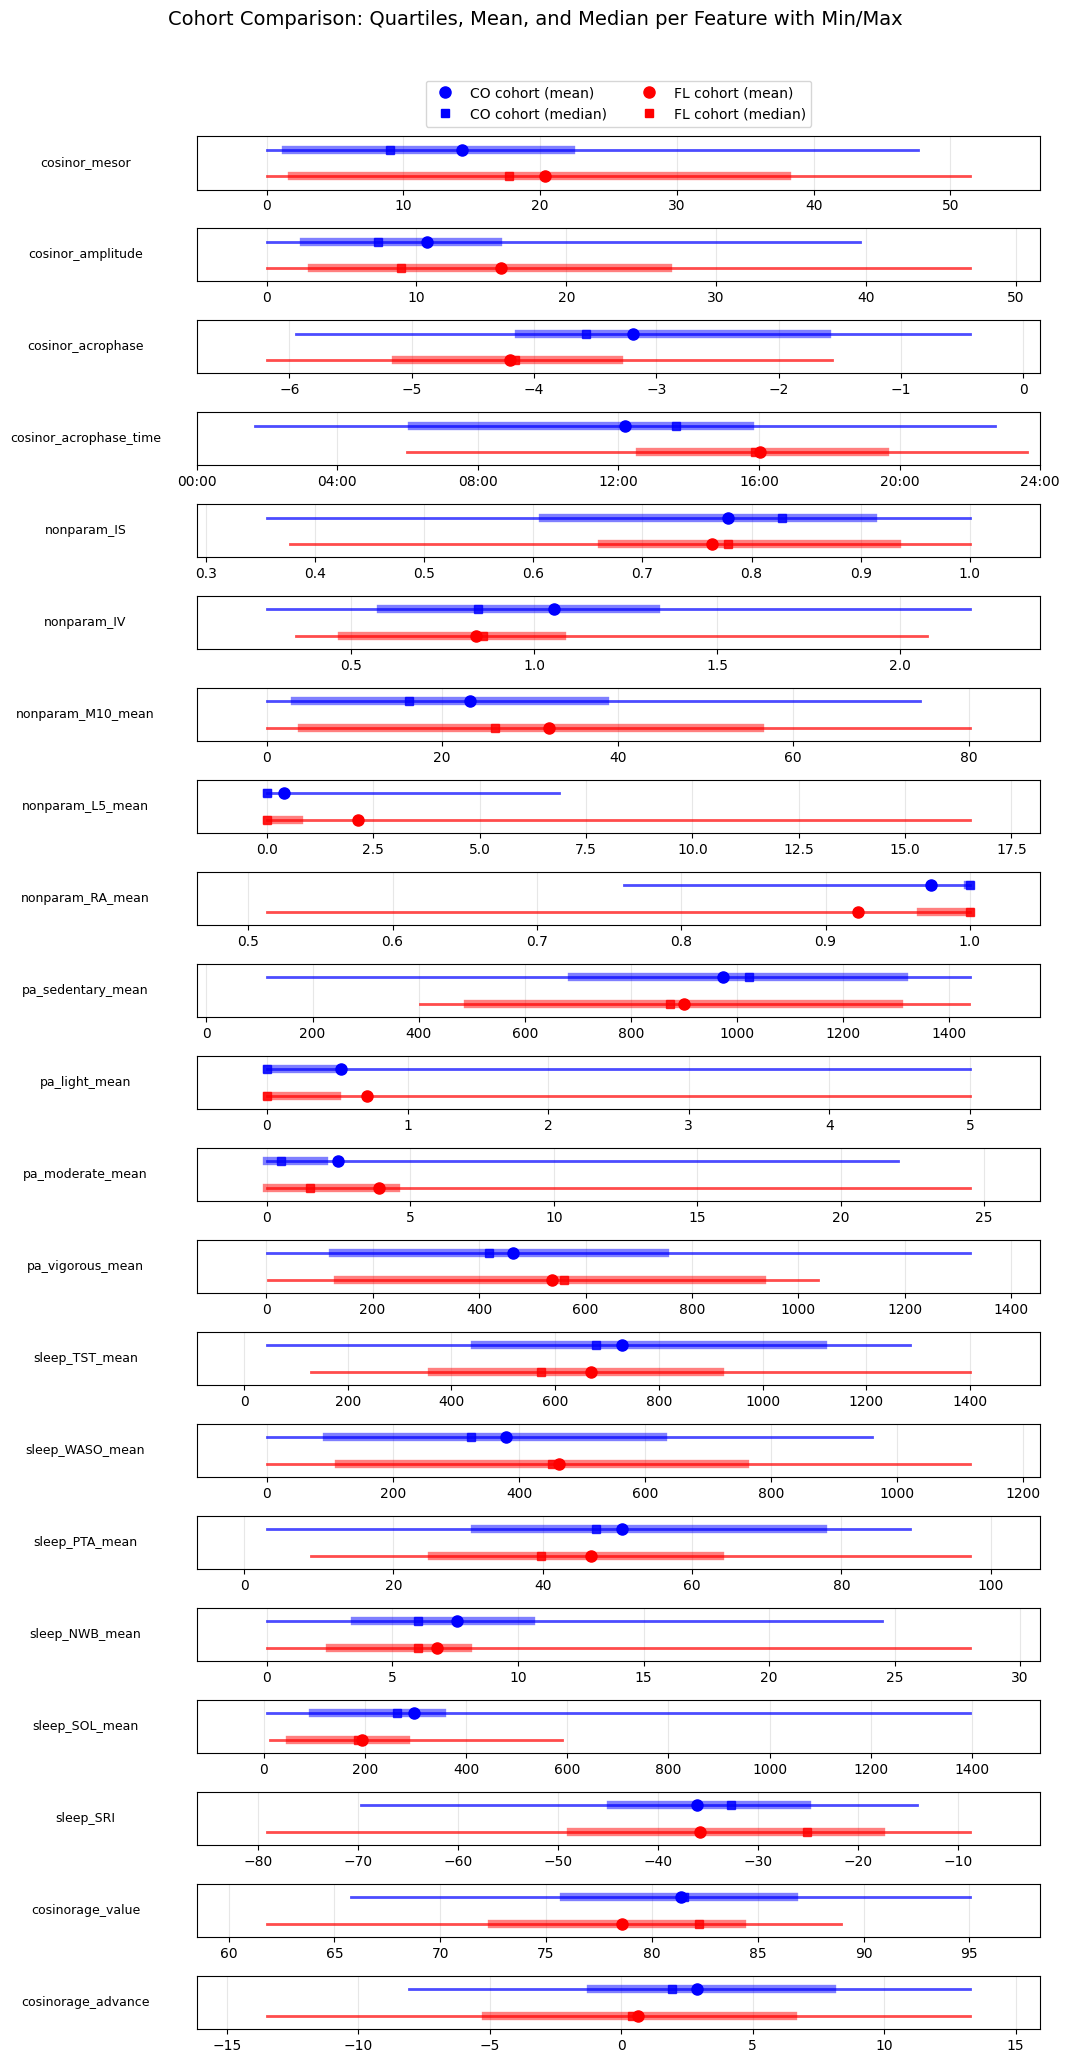

In [10]:
plot_cohort_feature_comparison(co_features, fl_features, title=None, plot_minmax=True)